In [47]:
import pymc3 as pm
import theano
import theano.tensor as tt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import corner
import exoplanet as xo
#from exoplanet.distributions import Angle

import pymc3_ext as pmx
from celerite2.theano import terms, GaussianProcess

import astropy.units as u
from astropy import constants
from astropy.time import Time


# conversion constant from au to R_sun
au_to_R_sun = (constants.au / constants.R_sun).value

deg = np.pi / 180.0
rad_2_deg = 180 / np.pi
yr = 365.2422

In [48]:
import math
from sigfig import round

def get_median_sigma(pos):
    """
    Helper function to estimate median and sigma from posterior distribution
    Args:
        pos: array from posterior distribution
    Returns:
        (median,sigma): best fit value and 1 sigma uncertainty
    """
    temp = np.percentile(pos,[16,50,84])
    lower = temp[1]-temp[0]
    upper = temp[2]-temp[1]
    sigma = np.max([lower,upper])
    
    return (temp[1], sigma)

def fmt(val, sig):
    """
    Format val±sig with the uncertainty rounded to 2 significant figures
    and the central value matched to the same precision.
    Uses numpy rounding + f-strings (sigfig.round cannot preserve 2-sf uncertainty).
    """
    mag = math.floor(math.log10(abs(sig)))
    ndecimals = max(0, 1 - mag)      # decimal places needed for 2 sig figs
    factor = 10 ** (mag - 1)
    sig_r = np.round(sig / factor) * factor
    val_r = np.round(val / factor) * factor
    if ndecimals > 0:
        return f'{val_r:.{ndecimals}f}$\\pm${sig_r:.{ndecimals}f}'
    else:
        return f'{val_r:.0f}$\\pm${sig_r:.0f}'


In [49]:
def xy_to_V2(f, x ,y , wv, u, v, fres):
    """
    Helper function to estimate V2 model
    Args:
        f: flux ratio
        x: delta-RA in arcsec
        y: delta-DEC in arcsec
        wv: wavelenght (um)
        u,v: U/V projected baseline in meters
    Returns:
        model_v2: V^2 binary model
    """
    # constant : take into account astrometry in arcsec to radian & wave leght in micro meter 
    c =   np.pi/180/3600.*1e6
    # Model V^2 for unresolved components in a binary system (J.P. Berger and Damien Segransan 2007)
    model_v2 = ( 1 + f**2 + 2 * f * np.cos( 2 * np.pi * c * (u * x + v * y) / wv) ) / (1 + f + fres)**2
    
    return model_v2
    

In [50]:
# # Keck Interferometer V2 data from  Boden et al. 2005

d = {'vis2': [0.606, 0.450, 0.464, 0.455, 0.349, 0.330, 0.205, 0.213, 0.158, 0.156, 0.131, 0.149],
     'vis2_err': [0.110, 0.132, 0.042, 0.030, 0.026, 0.028, 0.019, 0.013, 0.027, 0.020, 0.018, 0.013],
     'u': [56.149, 56.093, 55.452, 55.317, 54.458, 54.333, 51.467, 51.267, 47.550, 47.292, 44.576, 43.519],
     'v': [54.824, 54.631, 52.975, 52.699, 51.227, 51.042, 47.784, 47.602, 44.771, 44.604, 43.013, 42.462],
     'MJD': [53101.3170, 53101.3180, 53101.3290, 53101.3310, 53101.3410, 53101.3420, 53101.3660, 53101.3670,
             53101.3890, 53101.3900, 53101.4030, 53101.4080],
    'wv':[2.147,2.147,2.147,2.147,2.147,2.147,2.147,2.147,2.147,2.147,2.147,2.147]}
df_vis2_6Abril2004 = pd.DataFrame(data=d)


d = {'vis2': [0.263, 0.243, 0.241, 0.324, 0.198, 0.187, 0.173],
     'vis2_err': [0.067, 0.052, 0.061, 0.063, 0.026, 0.035, 0.042],
     'u': [53.160, 52.912, 50.225, 49.885, 40.756, 40.151, 39.385],
     'v': [49.530, 49.249, 49.716, 46.445, 41.170, 40.910, 40.592],
     'MJD': [53013.5930, 53013.5950, 53013.6140, 53013.6160, 53013.6600, 53013.6620, 53013.6650],
    'wv': [2.15, 2.15,2.15,2.15,2.15,2.15,2.15]}
df_vis2_9Jan2004 = pd.DataFrame(data=d)


d = {'vis2': [0.580, 0.512, 0.248, 0.246, 0.114, 0.109],
     'vis2_err': [0.125, 0.163, 0.026, 0.034, 0.019, 0.017],
     'u': [47.509, 47.193, 42.427, 42.108, 39.028, 38.548],
     'v': [44.738, 44.535, 41.919, 41.768, 40.434, 40.245],
     'MJD': [53482.3460, 53482.3480, 53482.3700, 53482.3710, 53482.3830, 53482.3850],
    'wv': [2.147, 2.147, 2.147, 2.147, 2.147, 2.147]}
df_vis2_22abril2005 = pd.DataFrame(data=d)


d = {'vis2': [0.218, 0.219, 0.220],
     'vis2_err': [0.049, 0.060, 0.033],
     'u': [43.882,43.444,43.105],
     'v': [42.652,42.428,42.259],
     'MJD': [52781.2830, 52781.2850, 52781.2860],
    'wv': [2.147, 2.147, 2.147]}
df_vis2_22May2003 = pd.DataFrame(data=d)


d = {'vis2': [0.604, 0.604, 0.598, 0.568, 0.549, 0.542],
     'vis2_err': [0.036, 0.070, 0.085, 0.063, 0.068, 0.027],
     'u': [49.874, 49.675, 46.649, 46.413, 43.934, 43.665],
     'v': [46.435, 46.280, 44.207, 44.063, 42.680, 42.541],
     'MJD': [52747.3450, 52747.3460, 52747.3630, 52747.3640, 52747.3750, 52747.3760],
    'wv': [2.15, 2.15, 2.15, 2.15, 2.15, 2.15]}
df_vis2_18abril2003 = pd.DataFrame(data=d)

# Keck Interferometer V2 data to numpy for fitting
u_data_a05 = df_vis2_22abril2005['u'].to_numpy()
v_data_a05 = df_vis2_22abril2005['v'].to_numpy()
wavel_a05 = np.median(df_vis2_22abril2005['wv'].to_numpy())
t_vis_a05 = np.median(df_vis2_22abril2005['MJD'].to_numpy()) + 2400000.5 # [Julian Date]
vis_err_a05 = df_vis2_22abril2005['vis2_err'].to_numpy()
vis2_a05 = df_vis2_22abril2005['vis2'].to_numpy() 

u_data_a04 = df_vis2_6Abril2004['u'].to_numpy()
v_data_a04 = df_vis2_6Abril2004['v'].to_numpy()
wavel_a04 = np.median(df_vis2_6Abril2004['wv'].to_numpy())
t_vis_a04 = np.median(df_vis2_6Abril2004['MJD'].to_numpy()) + 2400000.5 # [Julian Date]
vis_err_a04 = df_vis2_6Abril2004['vis2_err'].to_numpy()
vis2_a04 = df_vis2_6Abril2004['vis2'].to_numpy() 

u_data_j04 = df_vis2_9Jan2004['u'].to_numpy()
v_data_j04 = df_vis2_9Jan2004['v'].to_numpy()
wavel_j04 = np.median(df_vis2_9Jan2004['wv'].to_numpy())
t_vis_j04 = np.median(df_vis2_9Jan2004['MJD'].to_numpy()) + 2400000.5 # [Julian Date]
vis_err_j04 = df_vis2_9Jan2004['vis2_err'].to_numpy()
vis2_j04 = df_vis2_9Jan2004['vis2'].to_numpy() 

u_data_m03 = df_vis2_22May2003['u'].to_numpy()
v_data_m03 = df_vis2_22May2003['v'].to_numpy()
wavel_m03 = np.median(df_vis2_22May2003['wv'].to_numpy())
t_vis_m03 = np.median(df_vis2_22May2003['MJD'].to_numpy()) + 2400000.5 # [Julian Date]
vis_err_m03 = df_vis2_22May2003['vis2_err'].to_numpy()
vis2_m03 = df_vis2_22May2003['vis2'].to_numpy() 

u_data_a03 = df_vis2_18abril2003['u'].to_numpy()
v_data_a03 = df_vis2_18abril2003['v'].to_numpy()
wavel_a03 = np.median(df_vis2_18abril2003['wv'].to_numpy())
t_vis_a03 = np.median(df_vis2_18abril2003['MJD'].to_numpy()) + 2400000.5 # [Julian Date]
vis_err_a03 = df_vis2_18abril2003['vis2_err'].to_numpy()
vis2_a03 = df_vis2_18abril2003['vis2'].to_numpy() 

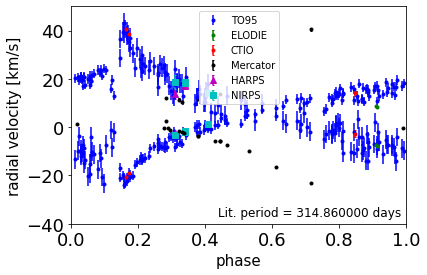

In [51]:

# Read RV data from Torres et al. 1995
RV_Ba = pd.read_csv('RV_Ba.csv')
RV_Bb = pd.read_csv('RV_Bb.csv')

t = RV_Ba['HJD'].to_numpy()
rva = RV_Ba['Ba'].to_numpy()
rva_err = RV_Ba['Ba_err'].to_numpy()

rvb = RV_Bb['Bb'].to_numpy()
rvb_err = RV_Bb['Bb_err'].to_numpy()

# Read RV data from ELODIE archive
RV_Ba = pd.read_csv('RV_Ba_ELODIE.csv') 
RV_Bb = pd.read_csv('RV_Bb_ELODIE.csv')

t_ELO = RV_Ba['MJD'].to_numpy()  + 2400000.5 # MJD to JD
rva_ELO = RV_Ba['Ba'].to_numpy()
rva_err_ELO = RV_Ba['Ba_err'].to_numpy()

rvb_ELO = RV_Bb['Bb'].to_numpy()
rvb_err_ELO = RV_Bb['Bb_err'].to_numpy()

# Read RV data from CTIO
RV_Ba = pd.read_csv('RV_Ba_CTIO.csv') 
RV_Bb = pd.read_csv('RV_Bb_CTIO.csv')

t_CTIO = RV_Ba['MJD'].to_numpy()  + 2400000.5 # MJD to JD
rva_CTIO = RV_Ba['Ba'].to_numpy()
rva_err_CTIO = RV_Ba['Ba_err'].to_numpy()

rvb_CTIO = RV_Bb['Bb'].to_numpy()
rvb_err_CTIO = RV_Bb['Bb_err'].to_numpy()

# Read RV data from Mercator
RV_Ba = pd.read_csv('RV_Ba_Mercator.csv') 
RV_Bb = pd.read_csv('RV_Bb_Mercator.csv')

t_Mercator = RV_Ba['MJD'].to_numpy()
rva_Mercator = RV_Ba['Ba'].to_numpy()
rva_err_Mercator = RV_Ba['Ba_err'].to_numpy()

t_MercatorBb = RV_Bb['MJD'].to_numpy()
rvb_Mercator = RV_Bb['Bb'].to_numpy()
rvb_err_Mercator = RV_Bb['Bb_err'].to_numpy()

# Read RV data from HARPS
RV_Ba = pd.read_csv('RV_Ba_HARPS.csv')
RV_Bb = pd.read_csv('RV_Bb_HARPS.csv')

t_HARPS = RV_Ba['MJD'].to_numpy() + 2400000.5  # MJD to JD
rva_HARPS = RV_Ba['Ba'].to_numpy()
rva_err_HARPS = RV_Ba['Ba_err'].to_numpy()

t_HARPSBb = RV_Bb['MJD'].to_numpy() + 2400000.5  # MJD to JD
rvb_HARPS = RV_Bb['Bb'].to_numpy()
rvb_err_HARPS = RV_Bb['Bb_err'].to_numpy()

# Read RV data from NIRPS
RV_Ba = pd.read_csv('RV_Ba_NIRPS.csv')
RV_Bb = pd.read_csv('RV_Bb_NIRPS.csv')

t_NIRPS = RV_Ba['MJD'].to_numpy() + 2400000.5  # MJD to JD
rva_NIRPS = RV_Ba['Ba'].to_numpy()
rva_err_NIRPS = RV_Ba['Ba_err'].to_numpy()

t_NIRPSBb = RV_Bb['MJD'].to_numpy() + 2400000.5  # MJD to JD
rvb_NIRPS = RV_Bb['Bb'].to_numpy()
rvb_err_NIRPS = RV_Bb['Bb_err'].to_numpy()


# Plot the observations "folded" on the published period:
# Zuñiga-Fernandez et al. (2021) DOI: 10.1051/0004-6361/202141985 

lit_period = 314.86

# Primary
plt.errorbar(
    (t % lit_period) / lit_period, rva, yerr=rva_err, fmt=".b", capsize=0, label="TO95"
)

plt.errorbar(
    (t_ELO % lit_period) / lit_period, rva_ELO, yerr=rva_err_ELO, fmt=".g", capsize=1, label="ELODIE"
)

plt.errorbar(
    (t_CTIO % lit_period) / lit_period, rva_CTIO, yerr=rva_err_CTIO, fmt=".r", capsize=1, label="CTIO"
)

plt.errorbar(
    (t_Mercator % lit_period) / lit_period, rva_Mercator, yerr=rva_err_Mercator, fmt=".k", capsize=1, label="Mercator"
)

plt.errorbar(
    (t_HARPS % lit_period) / lit_period, rva_HARPS, yerr=rva_err_HARPS, fmt="^m", capsize=1, label="HARPS"
)

plt.errorbar(
    (t_NIRPS % lit_period) / lit_period, rva_NIRPS, yerr=rva_err_NIRPS, fmt="sc", capsize=1, label="NIRPS"
)


# Secondary
plt.errorbar(
    (t % lit_period) / lit_period, rvb, yerr=rvb_err, fmt=".b", capsize=0)

plt.errorbar(
    (t_ELO % lit_period) / lit_period, rvb_ELO, yerr=rvb_err_ELO, fmt=".g", capsize=1
)

plt.errorbar(
    (t_CTIO % lit_period) / lit_period, rvb_CTIO, yerr=rvb_err_CTIO, fmt=".r", capsize=1
)

plt.errorbar(
    (t_MercatorBb % lit_period) / lit_period, rvb_Mercator, yerr=rvb_err_Mercator, fmt=".k", capsize=1
)

plt.errorbar(
    (t_HARPSBb % lit_period) / lit_period, rvb_HARPS, yerr=rvb_err_HARPS, fmt="^m", capsize=1
)

plt.errorbar(
    (t_NIRPSBb % lit_period) / lit_period, rvb_NIRPS, yerr=rvb_err_NIRPS, fmt="sc", capsize=1
)


plt.xlim(0, 1)
plt.ylim(-40, 50)
plt.annotate(
    "Lit. period = {0:.6f} days".format(lit_period),
    xy=(1, 0),
    xycoords="axes fraction",
    xytext=(-5, 5),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=12,
)

plt.legend(fontsize=10)

plt.ylabel("radial velocity [km/s]")
_ = plt.xlabel("phase")


In [52]:
# Read astrometry, we will use only the PIONIER based astrometry

astrometry_elipse = pd.read_csv('HD98800B_astrometry.csv')
astrometry_elipse_B = astrometry_elipse.iloc[:3]


t_astro = astrometry_elipse_B['MJD'].to_numpy()
astro_jds = t_astro + 2400000.5 # [Julian Date]
y = astrometry_elipse_B['y'].to_numpy()
x = astrometry_elipse_B['x'].to_numpy()

# Semi major axis (sigma_maj) as a astrometry x,y error to be conservative (just for visualization).
x_err = astrometry_elipse_B['sigma_maj'].to_numpy()
y_err = astrometry_elipse_B['sigma_maj'].to_numpy()

# The uncertainties in the astrometry from optical interferomtry should be represented with an elipse error
# i.e PA, sigma_maj, sigma_min (see Gallenne et al. 2015). 
astro_sigma_maj = astrometry_elipse_B['sigma_maj'].to_numpy()
astro_sigma_min = astrometry_elipse_B['sigma_min'].to_numpy()
astrometry_PA = astrometry_elipse_B['PA'].to_numpy()

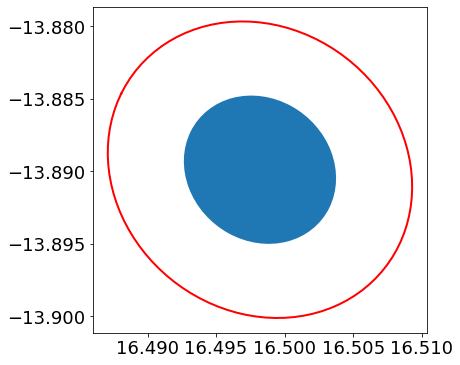

In [53]:
# Quick test to visualize the error elipse
from matplotlib.patches import Ellipse

th = np.linspace(0,2*np.pi,100)

angle = astrometry_PA[2]*deg

_x, _y = astro_sigma_maj[2]*np.cos(th), astro_sigma_min[2]*np.sin(th)
_x, _y = _x*np.cos(angle)+_y*np.sin(angle), -_y*np.cos(angle)+_x*np.sin(angle)
_x += x[2]
_y += y[2]

ellipse = Ellipse(xy=(x[2],y[2]),
                  width=astro_sigma_maj[2],
                  height=astro_sigma_min[2],
                  angle=astrometry_PA[2])

fig, ax = plt.subplots(nrows=1, figsize=(6, 6))

ax.add_artist(ellipse)
#print(angle*rad_2_deg)

plt.plot(_x, _y, linestyle='-', color='r', linewidth=2)

plt.show()

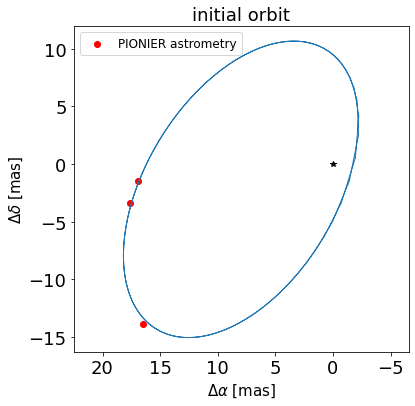

In [54]:
# For the relative astrometric fit, we only need the following parameters
# BaBb orbital parameters from Zúñiga-Fernández et al. 2021

a_ang_0 =  0.0222  # arcsec
parallax_0 = 0.022  # arcsec 
a_0 = a_ang_0 * au_to_R_sun / parallax_0
e_0 = 0.805
i_0 =  66.3 * deg  # [rad]
omega_0 = 104.5 * deg #omega_1
Omega_0 = 342.7 * deg
P_0 = 314.86 # days

#T0 = Time(1989.92, format="decimalyear")
#T0.format = "jd"
#T0 = T0.value  # [Julian Date]
T0 = 48707.5 + 2400000.5 # [Julian Date]

K1_0= 24.0
K2_0= 29.9

gamma_TO95_0 = 5.6
gamma_ELODIE_0 = 3.4
gamma_CTIO_0 = 6.4
gamma_Mercator_0 = 4.6

# instantiate the orbit
orbit = xo.orbits.KeplerianOrbit(
    a=a_0, t_periastron=T0, period=P_0, incl=i_0, ecc=e_0, omega=omega_0, Omega=Omega_0
)

# The position functions take an optional argument parallax to convert from
# physical units back to arcseconds
t_fine = np.linspace(T0 - P_0, T0 + P_0, num=200)  # days
rho, theta = theano.function([], orbit.get_relative_angles(t_fine, parallax_0))()

#y_model, x_model, z_model = theano.function([], orbit.get_relative_position(astro_jds, parallax))()

# Plot the orbit
fig, ax = plt.subplots(nrows=1, figsize=(6, 6))

xs = rho * np.cos(theta)  # X is north
ys = rho * np.sin(theta)  # Y is east
ax.plot(ys*1000, xs*1000, color="C0", lw=1)


ax.scatter(x, y, marker="o", color ='r', label = 'PIONIER astrometry')
#ax.scatter(x_model*1000,y_model*1000)

ax.set_ylabel(r"$\Delta \delta$ [mas]")
ax.set_xlabel(r"$\Delta \alpha$ [mas]")
ax.invert_xaxis()
ax.plot(0, 0, "k*")
ax.set_aspect("equal", "datalim")
ax.set_title("initial orbit")
ax.legend(loc='upper left', prop={'size': 12})
#print(astrometry_PA[2])

plt.show()

In [55]:

# We use the Zúñiga-Fernández et al. 2021 results as a "first guess" for the joint fit solution 

# for predicted orbits
t_fine = np.linspace(T0 - 500, T0 + 500, num=1000)


def get_model(parallax=None):
    with pm.Model() as model:

        if parallax is None:
            # Without an actual parallax measurement, we can model the orbit in units of arcseconds
            # by providing a fake_parallax and conversion constant
            plx = 1  # arcsec
        else:
            # Below we will run a version of this model where a measurement of parallax is provided
            # The measurement is in milliarcsec
            m_plx = pm.Bound(pm.Normal, lower=0, upper=100)(
                "m_plx", mu=parallax[0], sd=parallax[1], testval=parallax[0]
            )
            plx = pm.Deterministic("plx", 1e-3 * m_plx)

        a_ang = pm.Uniform("a_ang", 0.001, 0.3, testval=a_ang_0)
        a = pm.Deterministic("a", a_ang / plx)

        # We expect the period to be somewhere in the range of 315 days,
        # so we'll set a broad prior on logP
        logP = pm.Uniform(
            "logP", lower=np.log(300), upper=np.log(330), testval=np.log(P_0)
        )
        
        P = pm.Deterministic("P", tt.exp(logP))
        
        # Initial value from Boden et al. 2005
        Omega0 = Omega_0
        omega0 = omega_0
        omega = pm.Uniform("omega", lower=0*deg, upper=180*deg, testval=omega0)
        Omega = pm.Uniform("Omega", lower=0.0, upper=2*np.pi, testval=Omega0)
        
        ecc = pm.Uniform("ecc", lower=0.5, upper=0.99, testval=e_0)
    
        tp = pm.Normal("tp", T0, sd=30, testval=T0)

        # Geometric uniform prior on cos(incl)
        cos_incl = pm.Uniform(
            "cos_incl", lower=-1, upper=1, testval= np.cos(i_0)
        )
        incl = pm.Deterministic("incl", tt.arccos(cos_incl))
    

        # Set up the orbit
        orbit = xo.orbits.KeplerianOrbit(
            a= a * au_to_R_sun,
            t_periastron= tp,
            period= P,
            incl= incl,
            ecc= ecc,
            omega= omega,
            Omega= Omega,
        )

        if parallax is not None:
            pm.Deterministic("M_tot", orbit.m_total)
            
        #Primary
        K1 = pm.Uniform("K1", lower=0, upper=50, testval=K1_0)
        
        # Secondary
        K2 = pm.Uniform("K2", lower=0, upper=50, testval=K2_0)
        
        # The RV model
        gamma = pm.Uniform("gamma", lower=2, upper=8, testval=gamma_TO95_0)
        # ELODIE
        gamma_ELO = pm.Uniform("gamma_ELO", lower=0, upper=10, testval=gamma_ELODIE_0)
        # CTIO
        gamma_CTIO = pm.Uniform("gamma_CTIO", lower=0, upper=10, testval=gamma_CTIO_0)
        # Mercator
        gamma_Mercator = pm.Uniform("gamma_Mercator", lower=0, upper=10, testval=gamma_Mercator_0)
        # HARPS
        gamma_HARPS = pm.Uniform("gamma_HARPS", lower=0, upper=10, testval=gamma_TO95_0)
        # NIRPS
        gamma_NIRPS = pm.Uniform("gamma_NIRPS", lower=0, upper=10, testval=gamma_TO95_0)
        
        # Instrumental jitter
        logjit_TO95 = pm.Uniform("logjitterTO95", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        logjit_ELODIE_A = pm.Uniform("logjitterELODIE_A", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        logjit_ELODIE_B = pm.Uniform("logjitterELODIE_B", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        logjit_CTIO_A = pm.Uniform("logjitterCTIO_A", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        logjit_CTIO_B = pm.Uniform("logjitterCTIO_B", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        # Mercator
        logjit_Mercator_A = pm.Uniform("logjitterMercator_A", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        logjit_Mercator_B = pm.Uniform("logjitterMercator_B", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        # HARPS
        logjit_HARPS_A = pm.Uniform("logjitterHARPS_A", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        logjit_HARPS_B = pm.Uniform("logjitterHARPS_B", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        # NIRPS
        logjit_NIRPS_A = pm.Uniform("logjitterNIRPS_A", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        logjit_NIRPS_B = pm.Uniform("logjitterNIRPS_B", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
    
        jit_TO95 = pm.Deterministic("jitTO95", tt.exp(logjit_TO95))
        jit_ELODIE_A = pm.Deterministic("jitELODIE_A", tt.exp(logjit_ELODIE_A))
        jit_ELODIE_B = pm.Deterministic("jitELODIE_B", tt.exp(logjit_ELODIE_B))
        jit_CTIO_A = pm.Deterministic("jitCTIO_A", tt.exp(logjit_CTIO_A))
        jit_CTIO_B = pm.Deterministic("jitCTIO_B", tt.exp(logjit_CTIO_B))
        # Mercator
        jit_Mercator_A = pm.Deterministic("jitMercator_A", tt.exp(logjit_Mercator_A))
        jit_Mercator_B = pm.Deterministic("jitMercator_B", tt.exp(logjit_Mercator_B))
        # HARPS
        jit_HARPS_A = pm.Deterministic("jitHARPS_A", tt.exp(logjit_HARPS_A))
        jit_HARPS_B = pm.Deterministic("jitHARPS_B", tt.exp(logjit_HARPS_B))
        # NIRPS
        jit_NIRPS_A = pm.Deterministic("jitNIRPS_A", tt.exp(logjit_NIRPS_A))
        jit_NIRPS_B = pm.Deterministic("jitNIRPS_B", tt.exp(logjit_NIRPS_B))
        

        # Set up the radial velocity model
        def model_rv1(t,offset):
            return offset + orbit.get_radial_velocity(t,K=K1)
        
        def model_rv2(t,offset):
            return offset - orbit.get_radial_velocity(t,K=K2)
        
        #Primary
        rvmodel_a = pm.Deterministic("rvmodel_a", model_rv1(t,gamma))
        rvmodel_a_ELO = pm.Deterministic("rvmodel_a_ELO", model_rv1(t_ELO,gamma_ELO))
        rvmodel_a_CTIO = pm.Deterministic("rvmodel_a_CTIO", model_rv1(t_CTIO,gamma_CTIO))
        rvmodel_a_Mercator = pm.Deterministic("rvmodel_a_Mercator", model_rv1(t_Mercator,gamma_Mercator))
        rvmodel_a_HARPS = pm.Deterministic("rvmodel_a_HARPS", model_rv1(t_HARPS,gamma_HARPS))
        rvmodel_a_NIRPS = pm.Deterministic("rvmodel_a_NIRPS", model_rv1(t_NIRPS,gamma_NIRPS))
        
        #Secondary
        rvmodel_b = pm.Deterministic("rvmodel_b", model_rv2(t,gamma))
        rvmodel_b_ELO = pm.Deterministic("rvmodel_b_ELO", model_rv2(t_ELO,gamma_ELO))
        rvmodel_b_CTIO = pm.Deterministic("rvmodel_b_CTIO", model_rv2(t_CTIO,gamma_CTIO))
        rvmodel_b_Mercator = pm.Deterministic("rvmodel_b_Mercator", model_rv2(t_MercatorBb,gamma_Mercator))
        rvmodel_b_HARPS = pm.Deterministic("rvmodel_b_HARPS", model_rv2(t_HARPSBb,gamma_HARPS))
        rvmodel_b_NIRPS = pm.Deterministic("rvmodel_b_NIRPS", model_rv2(t_NIRPSBb,gamma_NIRPS))
        
        
        
        # get the total errors
        def get_err(rv_err, logjitter):
            return tt.sqrt(rv_err**2 + tt.exp(2*logjitter))

        # Condition on the observations
        pm.Normal("obs_a", mu=rvmodel_a, sd=get_err(rva_err, logjit_TO95), observed=rva)
        pm.Normal("obs_b", mu=rvmodel_b, sd=get_err(rvb_err, logjit_TO95), observed=rvb)
        #ELODIE
        pm.Normal("obs_a_ELO", mu=rvmodel_a_ELO, sd=get_err(rva_err_ELO, logjit_ELODIE_A), observed=rva_ELO)
        pm.Normal("obs_b_ELO", mu=rvmodel_b_ELO, sd=get_err(rvb_err_ELO, logjit_ELODIE_B), observed=rvb_ELO)
        #CTIO
        pm.Normal("obs_a_CTIO", mu=rvmodel_a_CTIO, sd=get_err(rva_err_CTIO, logjit_CTIO_A), observed=rva_CTIO)
        pm.Normal("obs_b_CTIO", mu=rvmodel_b_CTIO, sd=get_err(rvb_err_CTIO, logjit_CTIO_B), observed=rvb_CTIO)
        #Mercator
        pm.Normal("obs_a_Mercator", mu=rvmodel_a_Mercator, sd=get_err(rva_err_Mercator, logjit_Mercator_A), observed=rva_Mercator)
        pm.Normal("obs_b_Mercator", mu=rvmodel_b_Mercator, sd=get_err(rvb_err_Mercator, logjit_Mercator_B), observed=rvb_Mercator)
        #HARPS
        pm.Normal("obs_a_HARPS", mu=rvmodel_a_HARPS, sd=get_err(rva_err_HARPS, logjit_HARPS_A), observed=rva_HARPS)
        pm.Normal("obs_b_HARPS", mu=rvmodel_b_HARPS, sd=get_err(rvb_err_HARPS, logjit_HARPS_B), observed=rvb_HARPS)
        #NIRPS
        pm.Normal("obs_a_NIRPS", mu=rvmodel_a_NIRPS, sd=get_err(rva_err_NIRPS, logjit_NIRPS_A), observed=rva_NIRPS)
        pm.Normal("obs_b_NIRPS", mu=rvmodel_b_NIRPS, sd=get_err(rvb_err_NIRPS, logjit_NIRPS_B), observed=rvb_NIRPS)
        

        #Save O-C
        pm.Deterministic("OC_ELOa", (rva_ELO-rvmodel_a_ELO))
        pm.Deterministic("OC_ELOb", (rvb_ELO-rvmodel_b_ELO))

        #Save O-C
        pm.Deterministic("OC_CTIOa", (rva_CTIO-rvmodel_a_CTIO))
        pm.Deterministic("OC_CTIOb", (rvb_CTIO-rvmodel_b_CTIO))

        #Save O-C
        pm.Deterministic("OC_Mercatora", (rva_Mercator-rvmodel_a_Mercator))
        pm.Deterministic("OC_Mercatorb", (rvb_Mercator-rvmodel_b_Mercator))

        #Save O-C
        pm.Deterministic("OC_HARPSa", (rva_HARPS-rvmodel_a_HARPS))
        pm.Deterministic("OC_HARPSb", (rvb_HARPS-rvmodel_b_HARPS))

        #Save O-C
        pm.Deterministic("OC_NIRPSa", (rva_NIRPS-rvmodel_a_NIRPS))
        pm.Deterministic("OC_NIRPSb", (rvb_NIRPS-rvmodel_b_NIRPS))

        # Compute the model in x,y
        y_model, x_model, z_model = orbit.get_relative_position(astro_jds, plx)
        pm.Deterministic("x_model", x_model)
        pm.Deterministic("y_model", y_model)
        
        #Elipse error model
        # semi-major axis error
        Maj_err = (x_model - x/1000)*tt.cos(astrometry_PA*deg)+(y_model- y/1000)*tt.sin(astrometry_PA*deg)
        # semi-minor axis error
        Min_err = -(y_model-y/1000)*tt.cos(astrometry_PA*deg)+(x_model-x/1000)*tt.sin(astrometry_PA*deg)
        
        #pm.Deterministic('Maj_err', Maj_err)
        #pm.Deterministic('Min_err', Min_err)
        pm.Deterministic("x_err", (x/1000-x_model))
        pm.Deterministic("y_err", (y/1000-y_model))
        
        # define the likelihood function
        pm.Normal("sigmaMaj_obs", mu=Maj_err, sd=astro_sigma_maj/1000, observed=0.0)
        pm.Normal("sigmaMin_obs", mu=Min_err, sd=astro_sigma_min/1000, observed=0.0)
        
        
        # Set up predicted orbits for later plotting
        y_dense, x_dense, z_dense = orbit.get_relative_position(t_fine, plx)
        x_save = pm.Deterministic("x_save", x_dense)
        y_save = pm.Deterministic("y_save", y_dense)
        
        va_dense = orbit.get_radial_velocity(t_fine,K1)
        vb_dense = orbit.get_radial_velocity(t_fine,K2)
        
        va_save = pm.Deterministic("va_save",va_dense)
        vb_save = pm.Deterministic("vb_save",vb_dense)
        
        # Define flux ratio
        f = pm.Uniform("f", lower=0.45, upper=0.95, testval=0.76) # from Boden et al. 2005
        #fres = pm.Uniform("fres", lower=0.01, upper=1.0, testval=0.1)

        # V² jitter — one per epoch (same instrument, different nights → different conditions)
        logjit_v2_a03 = pm.Uniform("logjitterV2_a03", lower=-7.0, upper=np.log(0.5), testval=np.log(0.2))
        logjit_v2_m03 = pm.Uniform("logjitterV2_m03", lower=-7.0, upper=np.log(0.5), testval=np.log(0.2))
        logjit_v2_j04 = pm.Uniform("logjitterV2_j04", lower=-7.0, upper=np.log(0.5), testval=np.log(0.2))
        logjit_v2_a04 = pm.Uniform("logjitterV2_a04", lower=-7.0, upper=np.log(0.5), testval=np.log(0.2))
        logjit_v2_a05 = pm.Uniform("logjitterV2_a05", lower=-7.0, upper=np.log(0.5), testval=np.log(0.2))
        
        y_v2model_a05, x_v2model_a05, z_model = orbit.get_relative_position(t_vis_a05, plx)
        pm.Deterministic("x_v2model_a05", x_v2model_a05)
        pm.Deterministic("y_v2model_a05", y_v2model_a05)
        
        y_v2model_a04, x_v2model_a04, z_model = orbit.get_relative_position(t_vis_a04, plx)
        pm.Deterministic("x_v2model_a04", x_v2model_a04)
        pm.Deterministic("y_v2model_a04", y_v2model_a04)
        
        y_v2model_a03, x_v2model_a03, z_model = orbit.get_relative_position(t_vis_a03, plx)
        pm.Deterministic("x_v2model_a03", x_v2model_a03)
        pm.Deterministic("y_v2model_a03", y_v2model_a03)
        
        y_v2model_m03, x_v2model_m03, z_model = orbit.get_relative_position(t_vis_m03, plx)
        pm.Deterministic("x_v2model_m03", x_v2model_m03)
        pm.Deterministic("y_v2model_m03", y_v2model_m03)
        
        y_v2model_j04, x_v2model_j04, z_model = orbit.get_relative_position(t_vis_j04, plx)
        pm.Deterministic("x_v2model_j04", x_v2model_j04)
        pm.Deterministic("y_v2model_j04", y_v2model_j04)
        
        # Model V^2 for unresolved components in a binary system (J.P. Berger and Damien Segransan 2007)
        # constant : take into account astrometry in arcsec to radian & wavelength in micro meter 
        c =   np.pi/180/3600.*1e6
        
        model_v2_a03 = ( 1 + f**2 + 2 * f * tt.cos( 2 * np.pi * c * (u_data_a03 * x_v2model_a03 + v_data_a03 * y_v2model_a03) / wavel_a03) ) / (1 + f)**2 # + fres)**2
        model_v2_a04 = ( 1 + f**2 + 2 * f * tt.cos( 2 * np.pi * c * (u_data_a04 * x_v2model_a04 + v_data_a04 * y_v2model_a04) / wavel_a04) ) / (1 + f)**2 # + fres)**2
        model_v2_a05 = ( 1 + f**2 + 2 * f * tt.cos( 2 * np.pi * c * (u_data_a05 * x_v2model_a05 + v_data_a05 * y_v2model_a05) / wavel_a05) ) / (1 + f)**2 # + fres)**2
        model_v2_m03 = ( 1 + f**2 + 2 * f * tt.cos( 2 * np.pi * c * (u_data_m03 * x_v2model_m03 + v_data_m03 * y_v2model_m03) / wavel_m03) ) / (1 + f)**2 # + fres)**2
        model_v2_j04 = ( 1 + f**2 + 2 * f * tt.cos( 2 * np.pi * c * (u_data_j04 * x_v2model_j04 + v_data_j04 * y_v2model_j04) / wavel_j04) ) / (1 + f)**2 # + fres)**2


        # define the likelihood function
        pm.Normal("v2_obs_a03", mu= model_v2_a03, sd=get_err(vis_err_a03, logjit_v2_a03), observed=vis2_a03)
        pm.Normal("v2_obs_a4", mu= model_v2_a04, sd=get_err(vis_err_a04, logjit_v2_a04), observed=vis2_a04)
        pm.Normal("v2_obs_a05", mu= model_v2_a05, sd=get_err(vis_err_a05, logjit_v2_a05), observed=vis2_a05)
        pm.Normal("v2_obs_m03", mu= model_v2_m03, sd=get_err(vis_err_m03, logjit_v2_m03), observed=vis2_m03)
        pm.Normal("v2_obs_j04", mu= model_v2_j04, sd=get_err(vis_err_j04, logjit_v2_j04), observed=vis2_j04)
        
        # Determine physical parameters from orbit (Torres et al. 2010, Gallenne et al. 2019)
        c1 = 1.036149E-7
        c2 = 9.191940E-5
        # Masses
        M1_save = pm.Deterministic("M1_save", 
                                   (c1 * (K1 + K2)**2 * K2 * P * (1- ecc**2)**(3.0/2) ) / (tt.sin(incl)**3))
        
        M2_save = pm.Deterministic("M2_save", 
                                   (c1 * (K1 + K2)**2 * K1 * P * (1- ecc**2)**(3.0/2) ) / (tt.sin(incl)**3))
        
        M_t = pm.Deterministic("Mt_save", M1_save + M2_save)
        
        # semi-major axis in AU
        a_AU = pm.Deterministic("a_AU", 
                                    (c2 * (K1 + K2) * P * (1 -ecc**2)**(1/2)) / tt.sin(incl))
        
        # Parallax (mas)
        plx_save = pm.Deterministic("plx_save", (a_ang/a_AU)*1000)
        
        # astrometry para P108
        #y_enero, x_enero, z_model = orbit.get_relative_position(t_enero, plx)
        #pm.Deterministic("x_enero", x_enero)
        #pm.Deterministic("y_enero", y_enero)
        #y_febrero, x_febrero, z_model = orbit.get_relative_position(t_febrero, plx)
        #pm.Deterministic("x_febrero", x_febrero)
        #pm.Deterministic("y_febrero", y_febrero)
        #y_marzo, x_marzo, z_model = orbit.get_relative_position(t_marzo, plx)
        #pm.Deterministic("x_marzo", x_marzo)
        #pm.Deterministic("y_marzo", y_marzo)

        
        # Optimize to find the initial parameters
        map_soln = model.test_point
        map_soln = pmx.optimize(map_soln)


    return model, map_soln

model, map_soln = get_model() 


optimizing logp for variables: [logjitterV2_a05, logjitterV2_a04, logjitterV2_j04, logjitterV2_m03, logjitterV2_a03, f, logjitterNIRPS_B, logjitterNIRPS_A, logjitterHARPS_B, logjitterHARPS_A, logjitterMercator_B, logjitterMercator_A, logjitterCTIO_B, logjitterCTIO_A, logjitterELODIE_B, logjitterELODIE_A, logjitterTO95, gamma_NIRPS, gamma_HARPS, gamma_Mercator, gamma_CTIO, gamma_ELO, gamma, K2, K1, cos_incl, tp, ecc, Omega, omega, logP, a_ang]


message: Desired error not necessarily achieved due to precision loss.
logp: -7274.922446152407 -> -869.2323262268058


0.6873494626319924


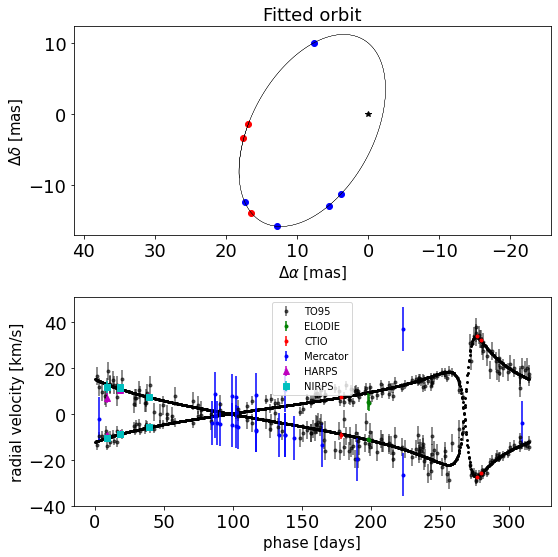

In [56]:

period = map_soln["P"]
gamma = map_soln["gamma"]
gamma2 = map_soln["gamma_ELO"]
gamma3 = map_soln["gamma_CTIO"]
gamma4 = map_soln["gamma_Mercator"]
gamma5 = map_soln["gamma_HARPS"]
gamma6 = map_soln["gamma_NIRPS"]

print(map_soln["f"])

fig, axes = plt.subplots(2, 1, figsize=(8, 8))

ax = axes[0]

ax.set_ylabel(r"$\Delta \delta$ [mas]")
ax.scatter(x, y, marker='o', color='r')
ax.plot(map_soln["x_save"]*1000, map_soln["y_save"]*1000, color = "k", lw=0.2)

ax.scatter(map_soln["x_v2model_a03"]*1000, map_soln["y_v2model_a03"]*1000, color = "b",
           label='KI data phase coverage')
ax.scatter(map_soln["x_v2model_a04"]*1000, map_soln["y_v2model_a04"]*1000, color = "b")
ax.scatter(map_soln["x_v2model_a05"]*1000, map_soln["y_v2model_a05"]*1000, color = "b")
ax.scatter(map_soln["x_v2model_j04"]*1000, map_soln["y_v2model_j04"]*1000, color = "b")
ax.scatter(map_soln["x_v2model_m03"]*1000, map_soln["y_v2model_m03"]*1000, color = "b")

ELO_errA = np.sqrt(rva_err_ELO**2 + np.exp(2 * np.median(map_soln["logjitterELODIE_A"])))
ELO_errB = np.sqrt(rvb_err_ELO**2 + np.exp(2 * np.median(map_soln["logjitterELODIE_B"])))
TO95_errA = np.sqrt(rva_err**2 + np.exp(2 * np.median(map_soln["logjitterTO95"])))
TO95_errB = np.sqrt(rvb_err**2 + np.exp(2 * np.median(map_soln["logjitterTO95"])))
CTIO_errA = np.sqrt(rva_err_CTIO**2 + np.exp(2 * np.median(map_soln["logjitterCTIO_A"])))
CTIO_errB = np.sqrt(rvb_err_CTIO**2 + np.exp(2 * np.median(map_soln["logjitterCTIO_B"])))
Mercator_errA = np.sqrt(rva_err_Mercator**2 + np.exp(2 * np.median(map_soln["logjitterMercator_A"])))
Mercator_errB = np.sqrt(rvb_err_Mercator**2 + np.exp(2 * np.median(map_soln["logjitterMercator_B"])))
HARPS_errA = np.sqrt(rva_err_HARPS**2 + np.exp(2 * np.median(map_soln["logjitterHARPS_A"])))
HARPS_errB = np.sqrt(rvb_err_HARPS**2 + np.exp(2 * np.median(map_soln["logjitterHARPS_B"])))
NIRPS_errA = np.sqrt(rva_err_NIRPS**2 + np.exp(2 * np.median(map_soln["logjitterNIRPS_A"])))
NIRPS_errB = np.sqrt(rvb_err_NIRPS**2 + np.exp(2 * np.median(map_soln["logjitterNIRPS_B"])))

ax.set_xlabel(r"$\Delta \alpha$ [mas]")
ax.invert_xaxis()
ax.plot(0, 0, "k*")
ax.set_aspect("equal", "datalim")
ax.set_title("Fitted orbit")

ax = axes[1]
ax.errorbar(t % period, rva - gamma, yerr=TO95_errA, fmt=".k", alpha=0.6, label="TO95")
ax.errorbar(t % period, rvb - gamma, yerr=TO95_errB, fmt=".k", alpha=0.6)
ax.errorbar(t_ELO % period, rva_ELO - gamma2, yerr=ELO_errA, fmt=".g", label="ELODIE")
ax.errorbar(t_ELO % period, rvb_ELO - gamma2, yerr=ELO_errB, fmt=".g")
ax.errorbar(t_CTIO % period, rva_CTIO - gamma3, yerr=CTIO_errA, fmt=".r", label="CTIO")
ax.errorbar(t_CTIO % period, rvb_CTIO - gamma3, yerr=CTIO_errB, fmt=".r")
ax.errorbar(t_Mercator % period, rva_Mercator - gamma4, yerr=Mercator_errA, fmt=".b", label="Mercator")
ax.errorbar(t_MercatorBb % period, rvb_Mercator - gamma4, yerr=Mercator_errB, fmt=".b")
ax.errorbar(t_HARPS % period, rva_HARPS - gamma5, yerr=HARPS_errA, fmt="^m", label="HARPS")
ax.errorbar(t_HARPSBb % period, rvb_HARPS - gamma5, yerr=HARPS_errB, fmt="^m")
ax.errorbar(t_NIRPS % period, rva_NIRPS - gamma6, yerr=NIRPS_errA, fmt="sc", label="NIRPS")
ax.errorbar(t_NIRPSBb % period, rvb_NIRPS - gamma6, yerr=NIRPS_errB, fmt="sc")

ax.scatter(t_fine % period, map_soln["va_save"], color = "k", marker='.',lw=0.01)
ax.scatter(t_fine % period, -map_soln["vb_save"], color = "k", marker='.',lw=0.01)

ax.set_ylabel("radial velocity [km/s]")
ax.set_xlabel("phase [days]")
ax.legend(fontsize=10)

plt.tight_layout()


In [57]:
#That looks fine, so now we can run the MCMC sampler:
np.random.seed(39091)
with model:
    trace = pmx.sample(
        tune=2500, draws=2000, start=map_soln, chains=7, cores=7, target_accept=0.95, init="adapt_full",
    )

/Users/macspeculoos/opt/anaconda3/envs/exoplanet_env/lib/python3.10/site-packages/pymc3_ext/sampling/sampling.py:109: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return pm.sample(draws=draws, tune=tune, model=model, step=step, **kwargs)
Multiprocess sampling (7 chains in 7 jobs)
INFO:pymc3:Multiprocess sampling (7 chains in 7 jobs)
NUTS: [logjitterV2_a05, logjitterV2_a04, logjitterV2_j04, logjitterV2_m03, logjitterV2_a03, f, logjitterNIRPS_B, logjitterNIRPS_A, logjitterHARPS_B, logjitterHARPS_A, logjitterMercator_B, logjitterMercator_A, logjitterCTIO_B, logjitterCTIO_A, logjitterELODIE_B, logjitterELODIE_A, logjitterTO95, gamma_NIRPS, gamma_HARPS, gamma_Mercator, gamma_CTIO, gamma_ELO, gamma, K2, K1, cos_incl, tp, ecc, Omega, omega, logP, a_ang]
INFO:pymc3:NUTS: [logjitterV2_a05, logjitterV2_a04, logjitterV2_

/Users/macspeculoos/opt/anaconda3/envs/exoplanet_env/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/macspeculoos/opt/anaconda3/envs/exoplanet_env/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/macspeculoos/opt/anaconda3/envs/exoplanet_env/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/macspeculoos/opt/anaconda3/envs/exoplanet_env/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/macspeculoos/opt/anaconda3/envs/exoplanet_env/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  ret

In [58]:
# Then we can look the summary of the trace and the convergence the key parameters:
with model:
    summary = pm.summary(
        trace,
        var_names=["a_ang", "Omega", "omega", "incl", "tp", "P", "plx_save", "K1", "K2","f"],
        round_to=4
    )

summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a_ang,2.200000e-02,0.0002,2.160000e-02,2.250000e-02,0.0000,0.0000,6053.7602,7764.9315,1.0008
Omega,6.004400e+00,0.0057,5.993600e+00,6.015000e+00,0.0001,0.0000,6862.6963,8408.4017,1.0006
omega,1.830200e+00,0.0059,1.819400e+00,1.841500e+00,0.0001,0.0001,6019.7012,7994.1673,1.0007
incl,1.142000e+00,0.0053,1.131800e+00,1.151800e+00,0.0001,0.0000,6122.8947,7953.3013,1.0007
tp,2.448709e+06,0.2144,2.448709e+06,2.448710e+06,0.0016,0.0011,17658.4118,9682.9435,1.0013
P,3.148785e+02,0.0001,3.148782e+02,3.148787e+02,0.0000,0.0000,16986.3704,10397.4494,1.0003
plx_save,2.190510e+01,0.3458,2.124590e+01,2.253920e+01,0.0042,0.0029,6882.4762,8683.0199,1.0004
K1,2.262820e+01,0.2945,2.207400e+01,2.318250e+01,0.0030,0.0021,9564.1141,8969.8298,1.0000
K2,2.810460e+01,0.3865,2.741090e+01,2.887380e+01,0.0038,0.0027,10693.4973,9351.0928,1.0010
f,6.620000e-01,0.0941,4.801000e-01,8.469000e-01,0.0012,0.0009,6288.1349,3886.5938,1.0012


Pandas support in corner is deprecated; use ArviZ directly


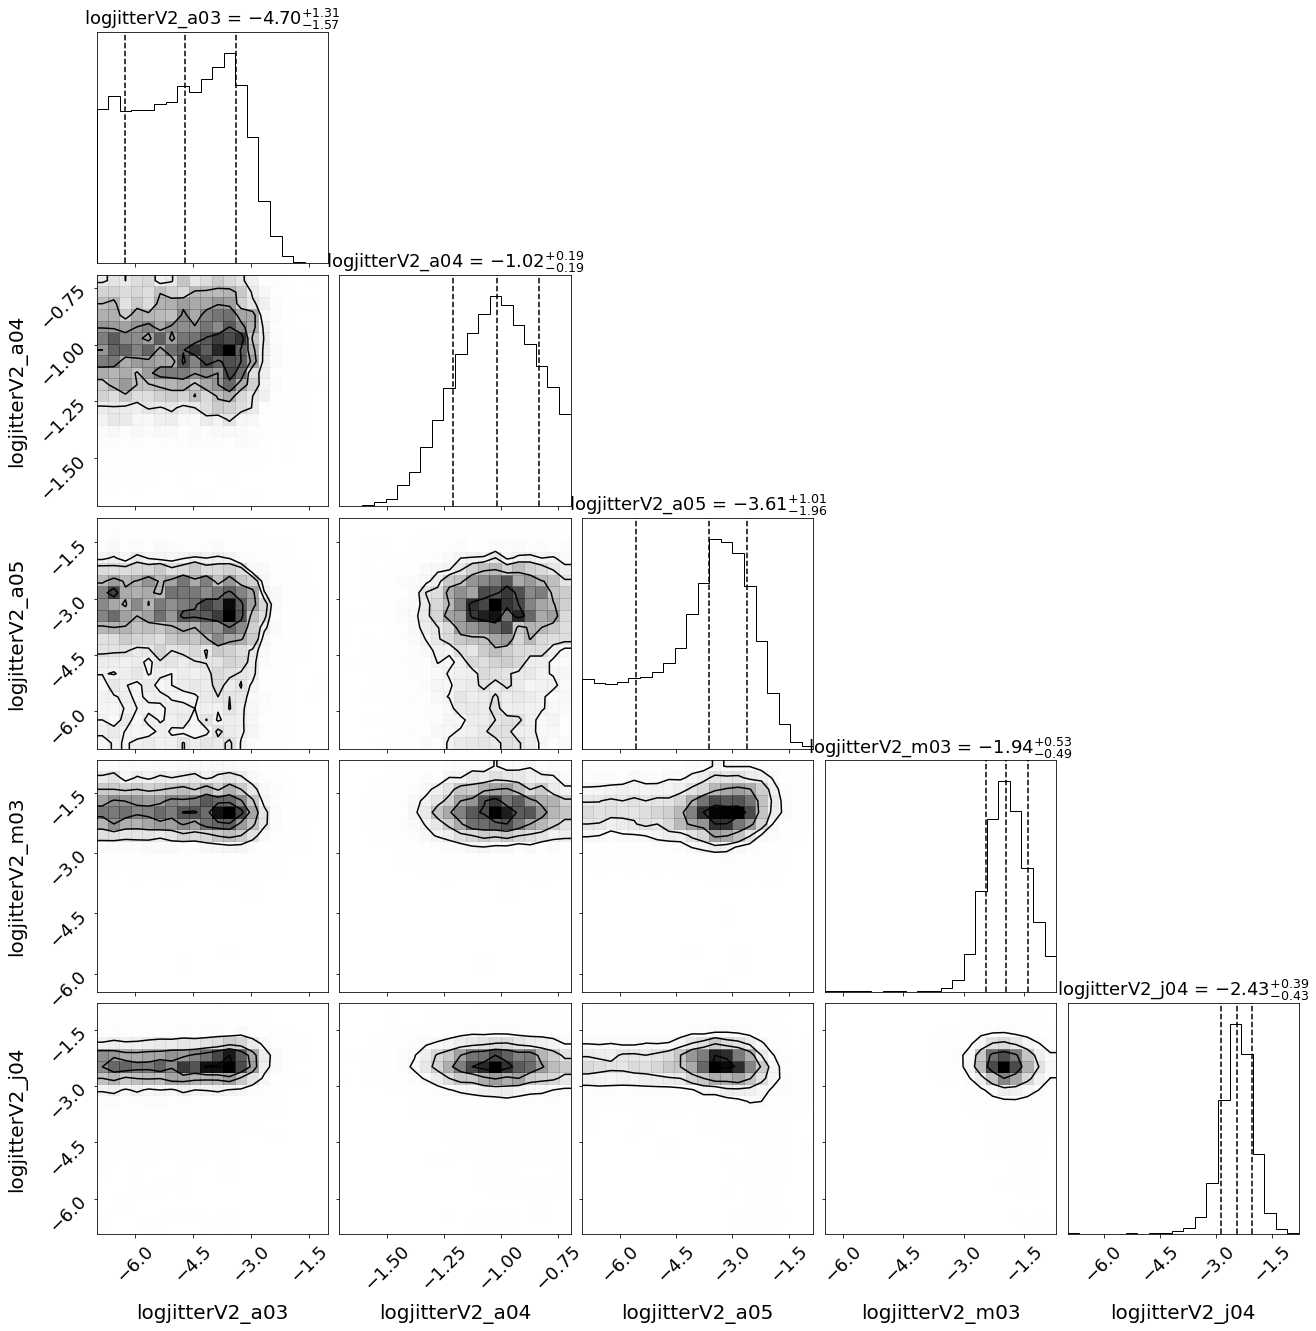

In [59]:
samples_jitt = pm.trace_to_dataframe(trace, varnames=["logjitterV2_a03", "logjitterV2_a04", "logjitterV2_a05", "logjitterV2_m03", "logjitterV2_j04"])

figure = corner.corner(samples_jitt,quantiles=[0.16, 0.5, 0.84], show_titles=True,
                  title_kwargs={"fontsize": 18}, label_kwargs=dict(fontsize=20), plot_datapoints=False)

figure.subplots_adjust(right=1.5,top=1.5)

for ax in figure.get_axes():
    ax.tick_params(axis='both', labelsize=18)

plt.show()

Period (days): 314.87848$\pm$0.00015
Tp (MJD): 48708.71$\pm$0.22
omega (deg): 104.86$\pm$0.34
Omega (deg): 344.02$\pm$0.33
i (deg): 65.43$\pm$0.31
a (mas): 22.04$\pm$0.22
e: 0.7819$\pm$0.0049
K1 (km/s): 22.63$\pm$0.29
K2 (km/s): 28.11$\pm$0.38
gamma TO95 (km/s): 5.65$\pm$0.14
gamma ELODIE (km/s): 3.84$\pm$0.44
gamma CTIO (km/s): 6.60$\pm$0.31
gamma Mercator (km/s): 4.74$\pm$0.27
gamma HARPS (km/s): 7.06$\pm$0.50
gamma NIRPS (km/s): 7.080$\pm$0.096
f2/f1 : 0.65$\pm$0.10
Pandas support in corner is deprecated; use ArviZ directly


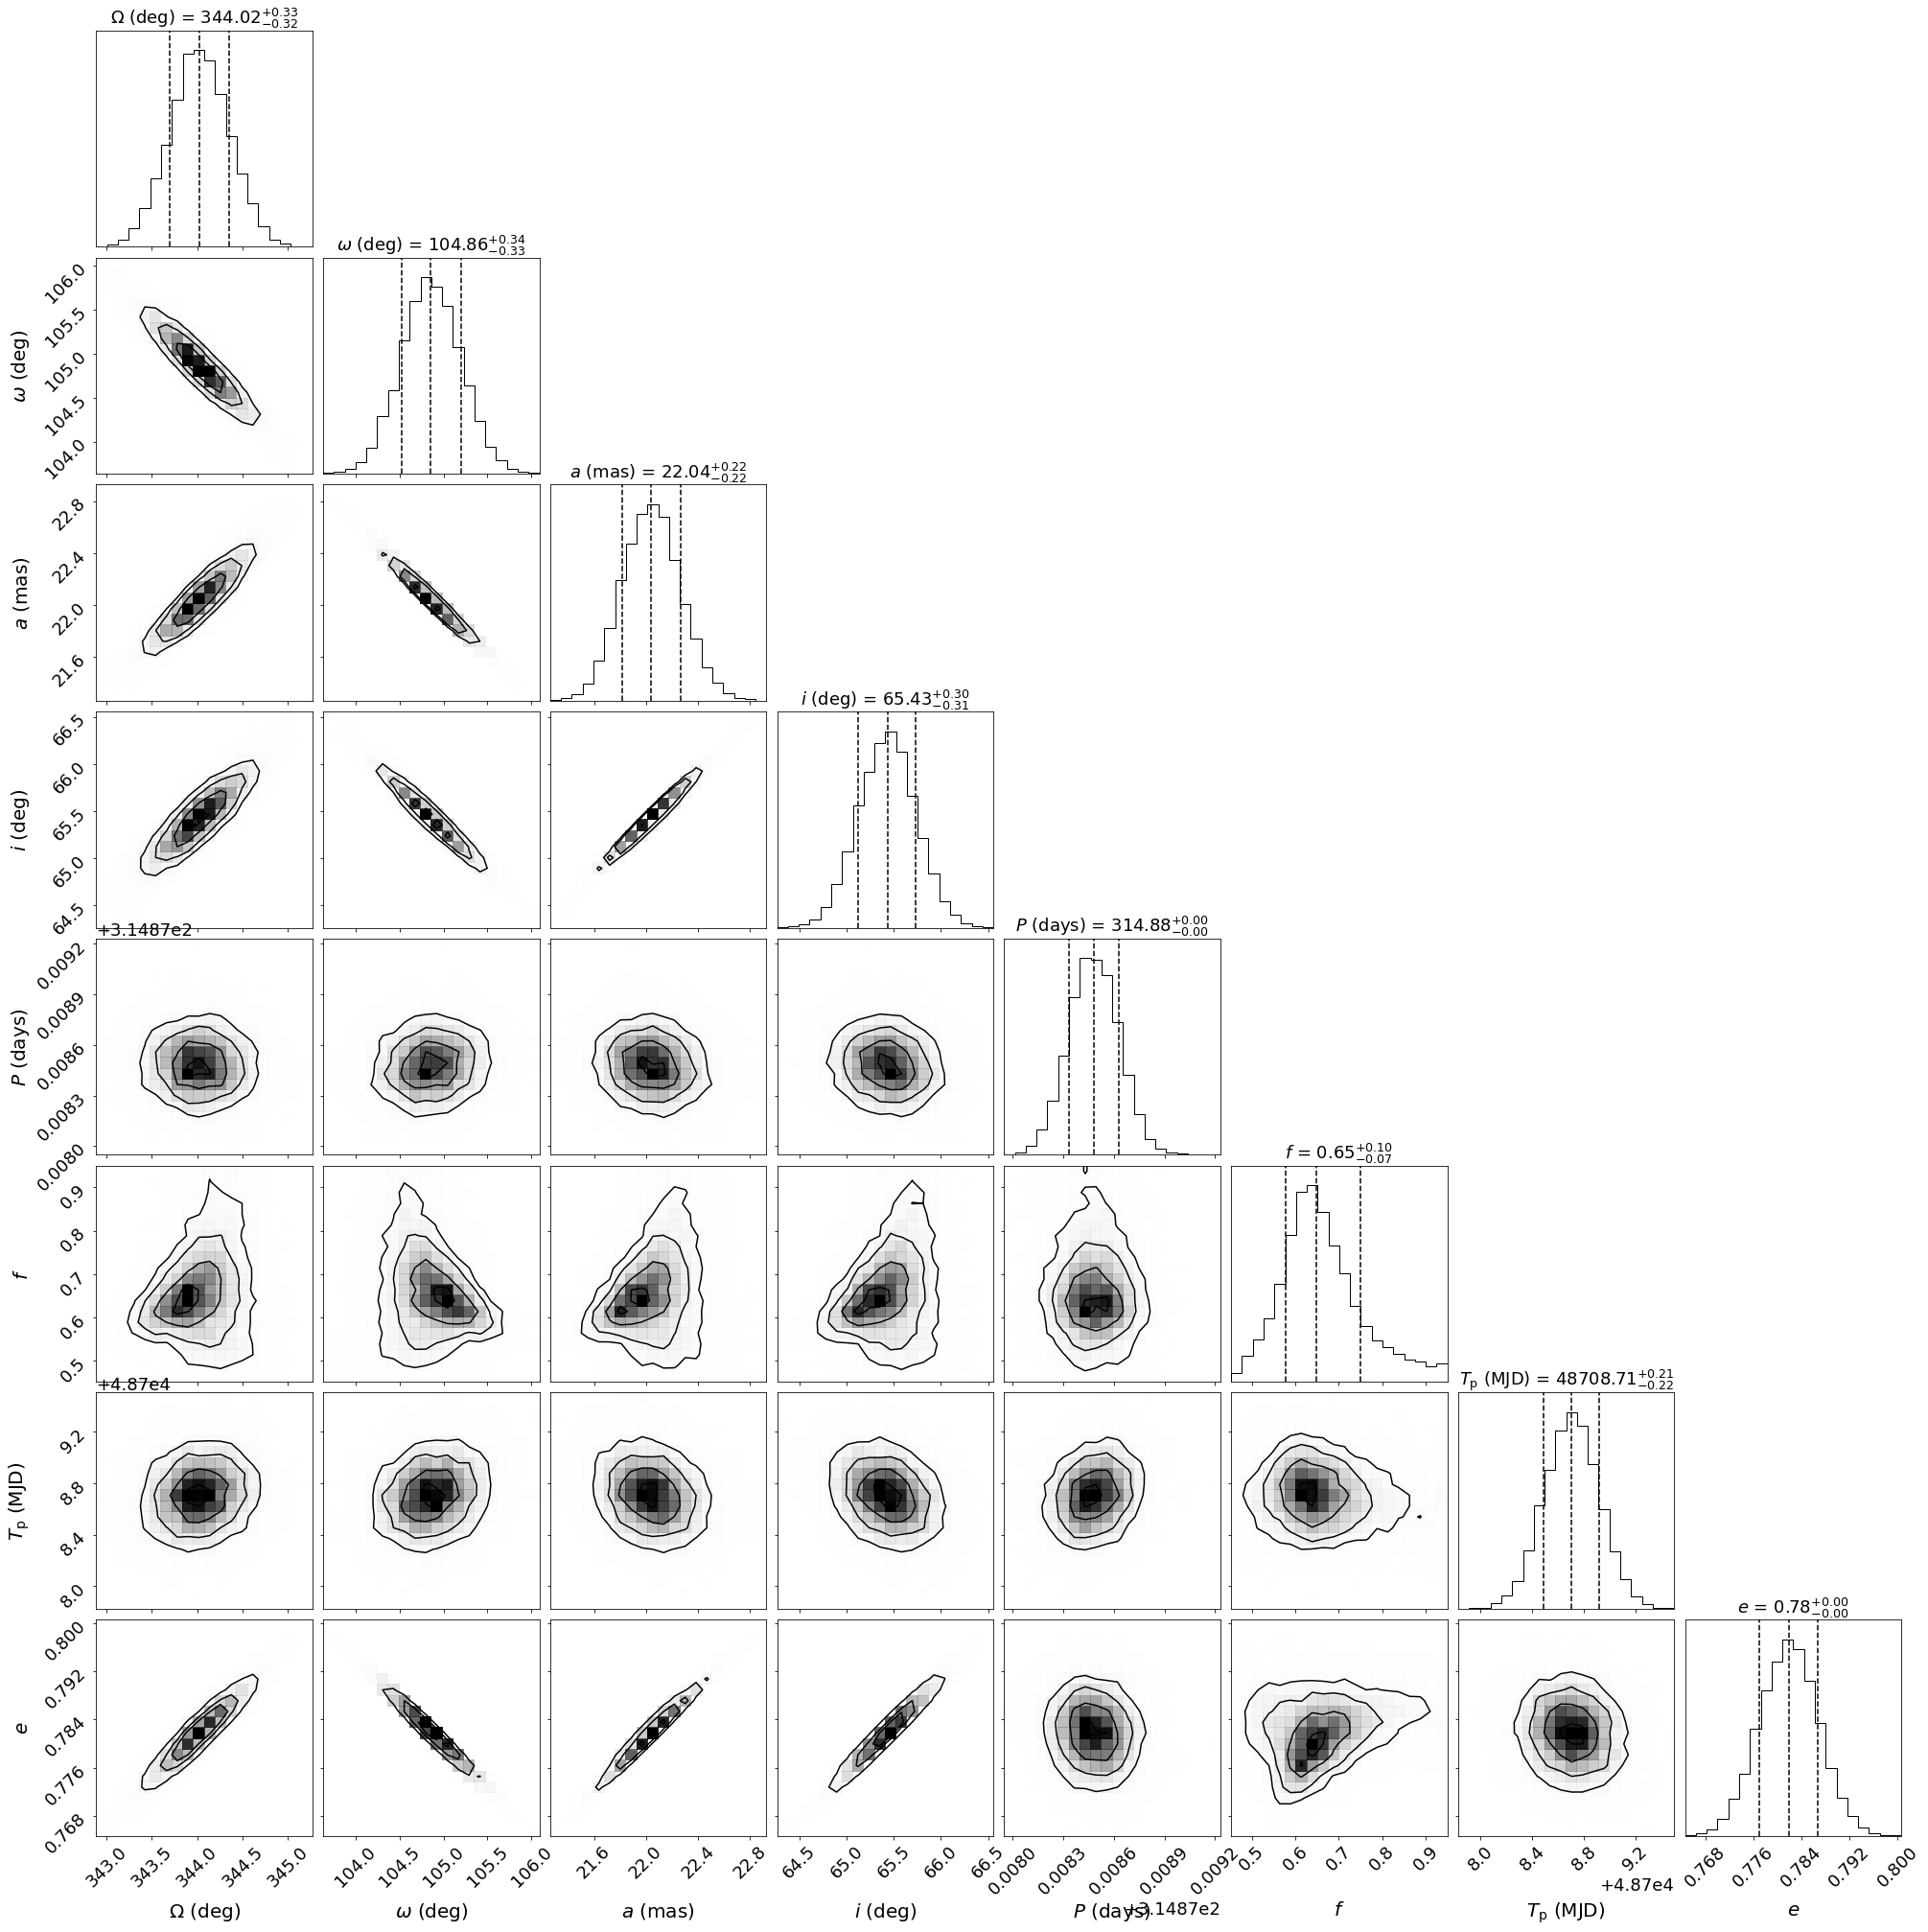

In [60]:
samples = pm.trace_to_dataframe(trace, varnames=["Omega"])
samples["$\Omega$ (deg)"] = (trace["Omega"] / deg) % 360
samples["$\omega$ (deg)"] = (trace["omega"] / deg) % 360
samples["$a$ (mas)"] = trace["a_ang"] * 1000
samples["$i$ (deg)"] = (trace["incl"] / deg) % 180
samples["$P$ (days)"] = trace["P"]
samples["$f$"] = trace["f"]
samples["$T_\mathrm{p}$ (MJD)"] = trace["tp"] - 2400000.5
samples["$e$"] = trace["ecc"]

period, period_s = get_median_sigma(trace["P"])
print("Period (days): "+fmt(period, period_s))

tp, tp_s = get_median_sigma(trace["tp"]- 2400000.5)
print("Tp (MJD): "+fmt(tp, tp_s))

omega, omega_s = get_median_sigma((trace["omega"] * rad_2_deg) % 360)
print("omega (deg): "+fmt(omega, omega_s))

Omega, Omega_s = get_median_sigma((trace["Omega"] * rad_2_deg) % 360)
print("Omega (deg): "+fmt(Omega, Omega_s))

inc, inc_s = get_median_sigma((trace["incl"] * rad_2_deg) % 180)
print("i (deg): "+fmt(inc, inc_s))

aang, aang_s = get_median_sigma(trace["a_ang"]*1000)
print("a (mas): "+fmt(aang, aang_s))

ecc, ecc_s = get_median_sigma(trace["ecc"])
print("e: "+fmt(ecc, ecc_s))

K1, K1_s = get_median_sigma(trace["K1"])
print("K1 (km/s): "+fmt(K1, K1_s))

K2, K2_s = get_median_sigma(trace["K2"])
print("K2 (km/s): "+fmt(K2, K2_s))

gamma, gamma_s = get_median_sigma(trace["gamma"])
print("gamma TO95 (km/s): "+fmt(gamma, gamma_s))

gamma2, gamma2_s = get_median_sigma(trace["gamma_ELO"])
print("gamma ELODIE (km/s): "+fmt(gamma2, gamma2_s))

gamma3, gamma3_s = get_median_sigma(trace["gamma_CTIO"])
print("gamma CTIO (km/s): "+fmt(gamma3, gamma3_s))

gamma4, gamma4_s = get_median_sigma(trace["gamma_Mercator"])
print("gamma Mercator (km/s): "+fmt(gamma4, gamma4_s))

gamma5, gamma5_s = get_median_sigma(trace["gamma_HARPS"])
print("gamma HARPS (km/s): "+fmt(gamma5, gamma5_s))

gamma6, gamma6_s = get_median_sigma(trace["gamma_NIRPS"])
print("gamma NIRPS (km/s): "+fmt(gamma6, gamma6_s))

f, f_s = get_median_sigma(trace["f"])
print("f2/f1 : "+fmt(f, f_s))

#fres, fres_s = get_median_sigma(trace["fres"])
#print("fres : "+fmt(fres, fres_s))

del samples["Omega"]
figure = corner.corner(samples,quantiles=[0.16, 0.5, 0.84], show_titles=True,
                  title_kwargs={"fontsize": 18}, label_kwargs=dict(fontsize=20), plot_datapoints=False)

figure.subplots_adjust(right=1.5,top=1.5)

for ax in figure.get_axes():
    ax.tick_params(axis='both', labelsize=18)
    
#plt.savefig('AaAb_corner.pdf')  

samples.to_csv('CSV/BaBb_posterior_V2.csv', index=False)

figure.savefig('Plots/BaBb_corner_V2.pdf',dpi=300,pad_inches=0.3,bbox_inches='tight')

plt.show()


In [61]:
latex_table = (
    r"\begin{table}" + "\n"
    r"\centering" + "\n"
    r"\caption{Orbital and spectroscopic parameters of HD\,98800\,BaBb}" + "\n"
    r"\begin{tabular}{lc}" + "\n"
    r"\hline\hline" + "\n"
    r"Parameter & Value \\" + "\n"
    r"\hline" + "\n"
    f"$P$ (days) & ${period:.4f} \\pm {period_s:.4f}$ \\\\\n"
    f"$T_{{\\rm p}}$ (MJD) & ${tp:.1f} \\pm {tp_s:.1f}$ \\\\\n"
    f"$\\omega$ (deg) & ${omega:.1f} \\pm {omega_s:.1f}$ \\\\\n"
    f"$\\Omega$ (deg) & ${Omega:.1f} \\pm {Omega_s:.1f}$ \\\\\n"
    f"$i$ (deg) & ${inc:.1f} \\pm {inc_s:.1f}$ \\\\\n"
    f"$a$ (mas) & ${aang:.1f} \\pm {aang_s:.1f}$ \\\\\n"
    f"$e$ & ${ecc:.3f} \\pm {ecc_s:.3f}$ \\\\\n"
    f"$K_1$ (km\\,s$^{{-1}}$) & ${K1:.1f} \\pm {K1_s:.1f}$ \\\\\n"
    f"$K_2$ (km\\,s$^{{-1}}$) & ${K2:.1f} \\pm {K2_s:.1f}$ \\\\\n"
    f"$\\gamma_{{\\rm TO95}}$ (km\\,s$^{{-1}}$) & ${gamma:.1f} \\pm {gamma_s:.1f}$ \\\\\n"
    f"$\\gamma_{{\\rm ELODIE}}$ (km\\,s$^{{-1}}$) & ${gamma2:.1f} \\pm {gamma2_s:.1f}$ \\\\\n"
    f"$\\gamma_{{\\rm CTIO}}$ (km\\,s$^{{-1}}$) & ${gamma3:.1f} \\pm {gamma3_s:.1f}$ \\\\\n"
    f"$\\gamma_{{\\rm Mercator}}$ (km\\,s$^{{-1}}$) & ${gamma4:.1f} \\pm {gamma4_s:.1f}$ \\\\\n"
    f"$\\gamma_{{\\rm HARPS}}$ (km\\,s$^{{-1}}$) & ${gamma5:.1f} \\pm {gamma5_s:.1f}$ \\\\\n"
    f"$\\gamma_{{\\rm NIRPS}}$ (km\\,s$^{{-1}}$) & ${gamma6:.1f} \\pm {gamma6_s:.1f}$ \\\\\n"
    r"\hline" + "\n"
    r"\end{tabular}" + "\n"
    r"\end{table}"
)
print(latex_table)


\begin{table}
\centering
\caption{Orbital and spectroscopic parameters of HD\,98800\,BaBb}
\begin{tabular}{lc}
\hline\hline
Parameter & Value \\
\hline
$P$ (days) & $314.8785 \pm 0.0001$ \\
$T_{\rm p}$ (MJD) & $48708.7 \pm 0.2$ \\
$\omega$ (deg) & $104.9 \pm 0.3$ \\
$\Omega$ (deg) & $344.0 \pm 0.3$ \\
$i$ (deg) & $65.4 \pm 0.3$ \\
$a$ (mas) & $22.0 \pm 0.2$ \\
$e$ & $0.782 \pm 0.005$ \\
$K_1$ (km\,s$^{-1}$) & $22.6 \pm 0.3$ \\
$K_2$ (km\,s$^{-1}$) & $28.1 \pm 0.4$ \\
$\gamma_{\rm TO95}$ (km\,s$^{-1}$) & $5.6 \pm 0.1$ \\
$\gamma_{\rm ELODIE}$ (km\,s$^{-1}$) & $3.8 \pm 0.4$ \\
$\gamma_{\rm CTIO}$ (km\,s$^{-1}$) & $6.6 \pm 0.3$ \\
$\gamma_{\rm Mercator}$ (km\,s$^{-1}$) & $4.7 \pm 0.3$ \\
$\gamma_{\rm HARPS}$ (km\,s$^{-1}$) & $7.1 \pm 0.5$ \\
$\gamma_{\rm NIRPS}$ (km\,s$^{-1}$) & $7.1 \pm 0.1$ \\
\hline
\end{tabular}
\end{table}


M1 : 0.760$\pm$0.020
M2 : 0.612$\pm$0.013
a (AU) : 1.0064$\pm$0.0076
plx : 21.90$\pm$0.34
d (pc) : 45.66$\pm$0.72
Pandas support in corner is deprecated; use ArviZ directly


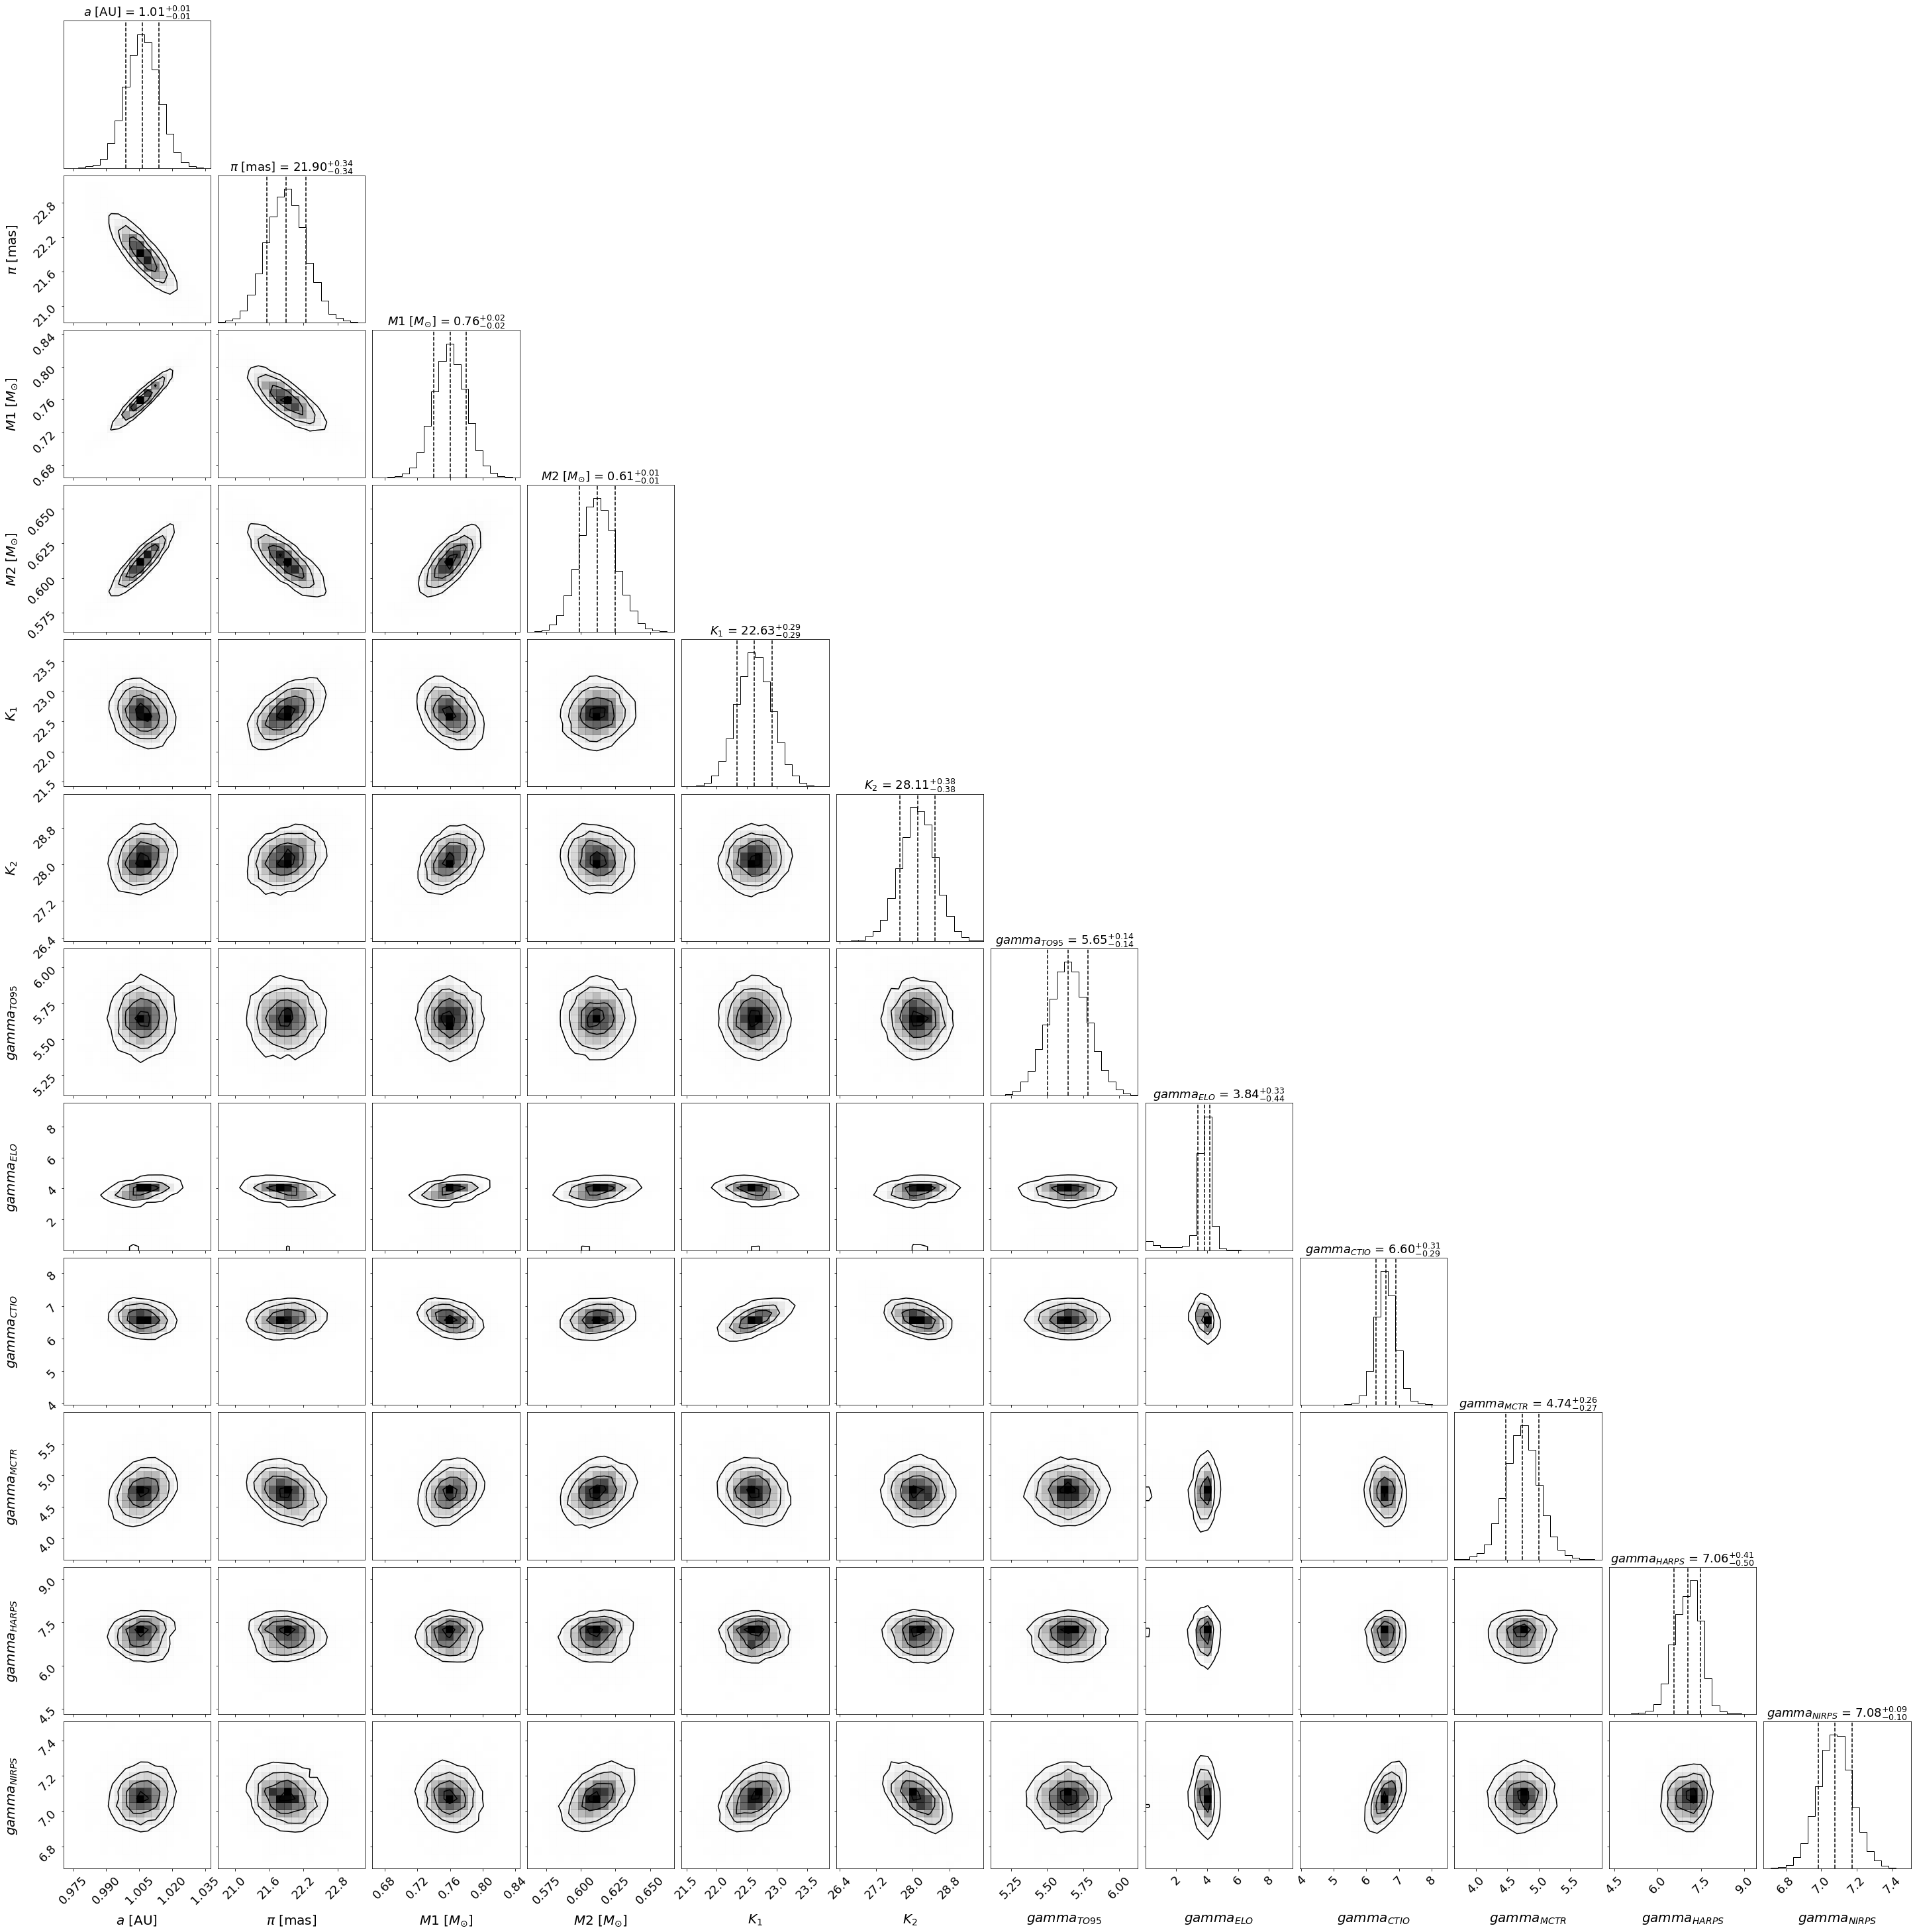

In [66]:
# Derived physical parameters

samples = pm.trace_to_dataframe(trace, varnames=["Omega"])
samples["$a$ [AU]"] = trace["a_AU"]
samples["$\pi$ [mas]"] = trace["plx_save"]
#samples["$i$ [deg]"] = (trace["incl"] / deg) % 360
#samples["$P$ [d]"] = trace["P"]
samples["$M1$ [$M_{\odot}$]"] = trace["M1_save"]
samples["$M2$ [$M_{\odot}$]"] = trace["M2_save"]
samples["$K_1$"] = trace["K1"]
samples["$K_2$"] = trace["K2"]
samples["$gamma_{TO95}$"] = trace["gamma"]
samples["$gamma_{ELO}$"] = trace["gamma_ELO"]
samples["$gamma_{CTIO}$"] = trace["gamma_CTIO"]
samples["$gamma_{MCTR}$"] = trace["gamma_Mercator"]
samples["$gamma_{HARPS}$"] = trace["gamma_HARPS"]
samples["$gamma_{NIRPS}$"] = trace["gamma_NIRPS"]

#Save masses and plx for later comparison
samples_sol1 = samples[["$M1$ [$M_{\odot}$]","$M2$ [$M_{\odot}$]","$\pi$ [mas]"]]

# Formated for publication
M11, M11_s = get_median_sigma(trace["M1_save"])
print("M1 : "+fmt(M11,M11_s))

M22, M22_s = get_median_sigma(trace["M2_save"])
print("M2 : "+fmt(M22,M22_s))

aAU, aAU_s = get_median_sigma(trace["a_AU"])
print("a (AU) : "+fmt(aAU,aAU_s))

plx, plx_s = get_median_sigma(trace["plx_save"])
print("plx : "+fmt(plx,plx_s))


dist_pc, dist_pc_s = get_median_sigma(1/(trace["plx_save"]/1000))
print("d (pc) : "+fmt(dist_pc, dist_pc_s))

del samples["Omega"]
figure = corner.corner(samples,quantiles=[0.16, 0.5, 0.84], show_titles=True,
                  title_kwargs={"fontsize": 18}, label_kwargs=dict(fontsize=20), plot_datapoints=False)

figure.subplots_adjust(right=1.5,top=1.5)

for ax in figure.get_axes():
    ax.tick_params(axis='both', labelsize=18)

samples.to_csv('CSV/BaBb_posterior_Mass_plx_RVs.csv', index=False)

figure.savefig('Plots/BaBb_corner_Mass_plx_RVs.pdf',dpi=300,pad_inches=0.3,bbox_inches='tight')


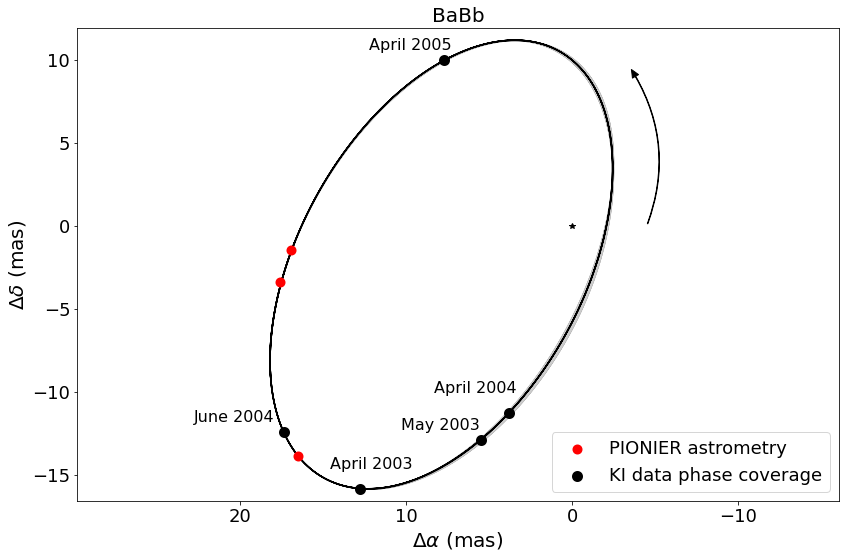

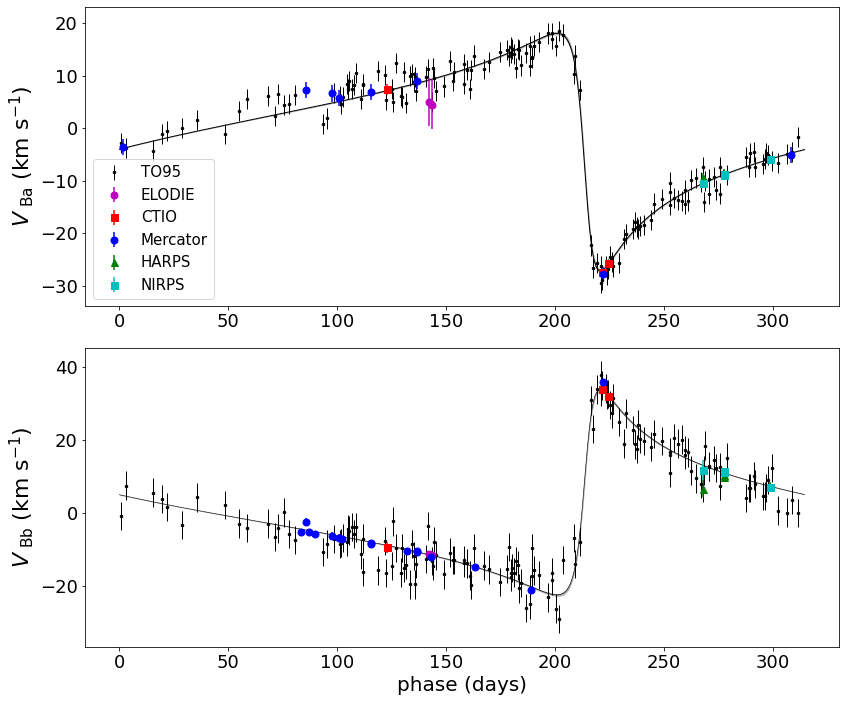

In [65]:
ELO_errA = np.sqrt(rva_err_ELO**2 + np.exp(2 * np.median(trace["logjitterELODIE_A"])))
ELO_errB = np.sqrt(rvb_err_ELO**2 + np.exp(2 * np.median(trace["logjitterELODIE_B"])))
TO95_errA = np.sqrt(rva_err**2 + np.exp(2 * np.median(trace["logjitterTO95"])))
TO95_errB = np.sqrt(rvb_err**2 + np.exp(2 * np.median(trace["logjitterTO95"])))
CTIO_errA = np.sqrt(rva_err_CTIO**2 + np.exp(2 * np.median(trace["logjitterCTIO_A"])))
CTIO_errB = np.sqrt(rvb_err_CTIO**2 + np.exp(2 * np.median(trace["logjitterCTIO_B"])))
Mercator_errA = np.sqrt(rva_err_Mercator**2 + np.exp(2 * np.median(trace["logjitterMercator_A"])))
Mercator_errB = np.sqrt(rvb_err_Mercator**2 + np.exp(2 * np.median(trace["logjitterMercator_B"])))
HARPS_errA = np.sqrt(rva_err_HARPS**2 + np.exp(2 * np.median(trace["logjitterHARPS_A"])))
HARPS_errB = np.sqrt(rvb_err_HARPS**2 + np.exp(2 * np.median(trace["logjitterHARPS_B"])))
NIRPS_errA = np.sqrt(rva_err_NIRPS**2 + np.exp(2 * np.median(trace["logjitterNIRPS_A"])))
NIRPS_errB = np.sqrt(rvb_err_NIRPS**2 + np.exp(2 * np.median(trace["logjitterNIRPS_B"])))


import matplotlib.patches as patches

#print(np.median(ELO_errA))
#print(np.median(ELO_errB))
#print(np.median(CTIO_errA))
#print(np.median(CTIO_errB))
#print(np.median(TO95_errA))
#print(np.median(TO95_errB))


fig, axes = plt.subplots(1, 1, figsize=(12, 8))

period = np.percentile(trace["P"], [16, 50, 84], axis=0)
gamma = np.percentile(trace["gamma"], [16, 50, 84], axis = 0)
gamma2 = np.percentile(trace["gamma_ELO"], [16, 50, 84], axis = 0)
gamma3 = np.percentile(trace["gamma_CTIO"], [16, 50, 84], axis = 0)
gamma4 = np.percentile(trace["gamma_Mercator"], [16, 50, 84], axis = 0)
gamma5 = np.percentile(trace["gamma_HARPS"], [16, 50, 84], axis = 0)
gamma6 = np.percentile(trace["gamma_NIRPS"], [16, 50, 84], axis = 0)

ax = axes

qx = np.percentile(trace["x_save"], [16, 50, 84], axis=0)
qy = np.percentile(trace["y_save"], [16, 50, 84], axis=0)

#x_e = np.percentile(trace["x_enero"], [16, 50, 84], axis=0)
#y_e = np.percentile(trace["y_enero"], [16, 50, 84], axis=0)

#x_f = np.percentile(trace["x_febrero"], [16, 50, 84], axis=0)
#y_f = np.percentile(trace["y_febrero"], [16, 50, 84], axis=0)

#x_m = np.percentile(trace["x_marzo"], [16, 50, 84], axis=0)
#y_m = np.percentile(trace["y_marzo"], [16, 50, 84], axis=0)


ax.set_ylabel(r"$\Delta \delta$ (mas)", fontsize=20)
ax.scatter(x, y, marker='o', color='r', label='PIONIER astrometry', zorder=3, lw=4)
ax.plot(qx[1]*1000, qy[1]*1000, color = "k", lw=1.5, zorder = 0)

ax.scatter(np.median(trace["x_v2model_a03"])*1000, np.median(trace["y_v2model_a03"])*1000, marker='o',
           color = "k", label='KI data phase coverage', lw=5)
ax.annotate('April 2003',xy=(np.median(trace["x_v2model_a03"])*1000, np.median(trace["y_v2model_a03"])*1000),
            xycoords='data', xytext=(-30, 20), textcoords='offset points', size=16)

ax.scatter(np.median(trace["x_v2model_a04"])*1000, np.median(trace["y_v2model_a04"])*1000, marker='o', 
           color = "k", lw=5)
ax.annotate('April 2004',xy=(np.median(trace["x_v2model_a04"])*1000, np.median(trace["y_v2model_a04"])*1000),
            xycoords='data', xytext=(-75, 20), textcoords='offset points', size=16)

ax.scatter(np.median(trace["x_v2model_a05"])*1000, np.median(trace["y_v2model_a05"])*1000, marker='o', 
           color = "k", lw=5)
ax.annotate('April 2005',xy=(np.median(trace["x_v2model_a05"])*1000, np.median(trace["y_v2model_a05"])*1000),
            xycoords='data', xytext=(-75, 10), textcoords='offset points', size=16)

ax.scatter(np.median(trace["x_v2model_j04"])*1000, np.median(trace["y_v2model_j04"])*1000, marker='o', 
           color = "k", lw=5)
ax.annotate('June 2004',xy=(np.median(trace["x_v2model_j04"])*1000, np.median(trace["y_v2model_j04"])*1000),
            xycoords='data', xytext=(-90, 10), textcoords='offset points', size=16)

ax.scatter(np.median(trace["x_v2model_m03"])*1000, np.median(trace["y_v2model_m03"])*1000, marker='o', 
           color = "k", lw=5)
ax.annotate('May 2003',xy=(np.median(trace["x_v2model_m03"])*1000, np.median(trace["y_v2model_m03"])*1000),
            xycoords='data', xytext=(-80, 10), textcoords='offset points', size=16)


#P108
#ax.scatter(np.median(trace["x_enero"])*1000, np.median(trace["y_enero"])*1000, marker='o', 
 #          color = "g", lw=5)
#ax.scatter(np.median(trace["x_febrero"])*1000, np.median(trace["y_febrero"])*1000, marker='s', 
 #          color = "g", lw=5)
#ax.scatter(np.median(trace["x_marzo"])*1000, np.median(trace["y_marzo"])*1000, marker='^', 
 #          color = "g", lw=5)



# 1 sigma orbit range
ax.fill_between(qx[0]*1000, qy[0]*1000, qy[2]*1000, color="k", lw =0.1, alpha = 0.2)
ax.fill_between(qx[2]*1000, qy[0]*1000, qy[2]*1000, color="k", lw=0.1, alpha = 0.2)
#ax.fill_between(qx[1]*1000, qy[0]*1000, qy[2]*1000, color="k", lw=0.1, alpha = 0.2)

style = "Simple, tail_width=0.5, head_width=7, head_length=8"
kw = dict(arrowstyle=style, color="k")

a3 = patches.FancyArrowPatch((-4.5, 0), (-3.5, 9.5),
                             connectionstyle="arc3,rad=.25", **kw)
plt.gca().add_patch(a3)

ax.legend(loc='lower right', prop={'size': 18})
ax.set_xlabel(r"$\Delta \alpha$ (mas)", fontsize=20)
ax.invert_xaxis()
ax.plot(0, 0, "k*")
ax.set_aspect("equal", "datalim")
ax.set_title("BaBb", fontsize=20)

plt.tight_layout()

plt.savefig('Plots/BaBb_Orbit_V2.pdf') 

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

 # Plot the folded model
x_fold = t_fine % period[1]
inds = np.argsort(x_fold)
va_model = trace["va_save"][:, inds]
vb_model = trace["vb_save"][:, inds]
va_model = np.percentile(va_model, [16, 50, 84], axis=0)
vb_model = np.percentile(vb_model, [16, 50, 84], axis=0)

ax = axes[0]
ax.set_ylabel("$V_{~\mathrm{Ba}}$ ($\mathrm{km~s^{-1}}$)", fontsize=22)
ax.fill_between(x_fold[inds], va_model[0], va_model[2], color="k", lw=0.1, alpha = 0.3)
ax.plot(x_fold[inds], va_model[1], color="k", lw=1.0)
ax.errorbar(t % period[1], rva - gamma[1], yerr=TO95_errA, fmt=".k", lw=1, ms=5, label='TO95')
ax.errorbar(t_ELO % period[1], rva_ELO - gamma2[1], yerr=ELO_errA, fmt="om",
            lw=1.5, ms = 7, label="ELODIE")
ax.errorbar(t_CTIO % period[1], rva_CTIO - gamma3[1], yerr=CTIO_errA, fmt="sr",
            lw=1.5, ms = 7, label="CTIO")
ax.errorbar(t_Mercator % period[1], rva_Mercator - gamma4[1], yerr=Mercator_errA, fmt="ob",
            lw=1.5, ms = 7, label="Mercator")
ax.errorbar(t_HARPS % period[1], rva_HARPS - gamma5[1], yerr=HARPS_errA, fmt="^g",
            lw=1.5, ms = 7, label="HARPS")
ax.errorbar(t_NIRPS % period[1], rva_NIRPS - gamma6[1], yerr=NIRPS_errA, fmt="sc",
            lw=1.5, ms = 7, label="NIRPS")
ax.legend(loc='lower left', prop={'size': 15})

ax = axes[1]
ax.fill_between(x_fold[inds], -vb_model[0], -vb_model[2], color="k", lw=0.1, alpha = 0.3)
ax.plot(x_fold[inds], -vb_model[1], color="k",lw=0.6)
ax.errorbar(t % period[1], rvb - gamma[1], yerr=TO95_errB, fmt=".k", lw=1, ms=5)
ax.errorbar(t_ELO % period[1], rvb_ELO - gamma2[1], yerr=ELO_errB, fmt="om",
            lw=1.5, ms = 7)
ax.errorbar(t_CTIO % period[1], rvb_CTIO - gamma3[1], yerr=CTIO_errB, fmt="sr",
            lw=1.5, ms = 7)
ax.errorbar(t_MercatorBb % period[1], rvb_Mercator - gamma4[1], yerr=Mercator_errB, fmt="ob",
            lw=1.5, ms = 7)
ax.errorbar(t_HARPSBb % period[1], rvb_HARPS - gamma5[1], yerr=HARPS_errB, fmt="^g",
            lw=1.5, ms = 7)
ax.errorbar(t_NIRPSBb % period[1], rvb_NIRPS - gamma6[1], yerr=NIRPS_errB, fmt="sc",
            lw=1.5, ms = 7)

ax.set_ylabel("$V_{~\mathrm{Bb}}$ ($\mathrm{km~s^{-1}}$)", fontsize=22)
ax.set_xlabel("phase (days)", fontsize=20)

plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)

plt.tight_layout()

plt.savefig('Plots/BaBb_RVOrbit_V2.pdf')


In [67]:
print("O-C CTIO A")
print(np.percentile(trace["OC_CTIOa"], [16, 50, 84], axis = 0)[1])
print(CTIO_errA)
print("O-C CTIO B")
print(np.percentile(trace["OC_CTIOb"], [16, 50, 84], axis = 0)[1])
print(CTIO_errB)
print("O-C ELODIE A")
print(np.percentile(trace["OC_ELOa"], [16, 50, 84], axis = 0)[1])
print(ELO_errA)
print("O-C ELODIE B")
print(np.percentile(trace["OC_ELOb"], [16, 50, 84], axis = 0)[1])
print(ELO_errB)
print("O-C Mercator A")
print(np.percentile(trace["OC_Mercatora"], [16, 50, 84], axis = 0)[1])
print(Mercator_errA)
print("O-C Mercator B")
print(np.percentile(trace["OC_Mercatorb"], [16, 50, 84], axis = 0)[1])
print(Mercator_errB)
#print("O-C astrometry")
#print(np.percentile(trace["sigmaMaj_obs"], [16, 50, 84], axis = 0)[1])
#print(astro_sigma_maj)

O-C CTIO A
[ 0.29153719 -0.25222915  0.19797715]
[1.00541136 0.22550388 0.22550388]
O-C CTIO B
[-0.49703332  0.2900518  -0.12365136]
[1.50164569 0.50491561 0.50491561]
O-C ELODIE A
[-4.24496328 -4.8194251 ]
[4.59626 4.59626]
O-C ELODIE B
[ 0.1997011  -0.07803535]
[0.3113158 0.3113158]
O-C Mercator A
[-0.98999764 -0.42803058  0.31883991  3.54987761  1.84699642  0.72557671
  0.51149281  0.37361998]
[1.48580591 1.4849132  1.49797337 1.55705594 1.63443544 1.55918319
 1.51443825 1.49302485]
O-C Mercator B
[-0.92088282  2.38986099 -0.38201869 -0.76213796 -0.34815025 -0.37378952
 -0.76045152 -0.75772878 -0.58463017  0.00352491  0.05129097  2.29925931
 -0.26914834 -0.4683832  -0.17268132  0.19539626]
[0.87140334 1.08614031 0.88194092 0.87153932 0.87252265 0.87530325
 0.89558014 0.88360839 0.87386771 0.87281371 0.87281371 0.91046185
 0.89246612 0.89171115 0.91734387 0.91401301]


In [68]:
M_total =trace["M2_save"] + trace["M1_save"]



Mt, Mt_s = get_median_sigma(M_total)
print("Total mass (M_sun): "+round(str(Mt), uncertainty=str(Mt_s), separation='$\pm$'))


Total mass (M_sun): 1.37$\pm$0.03


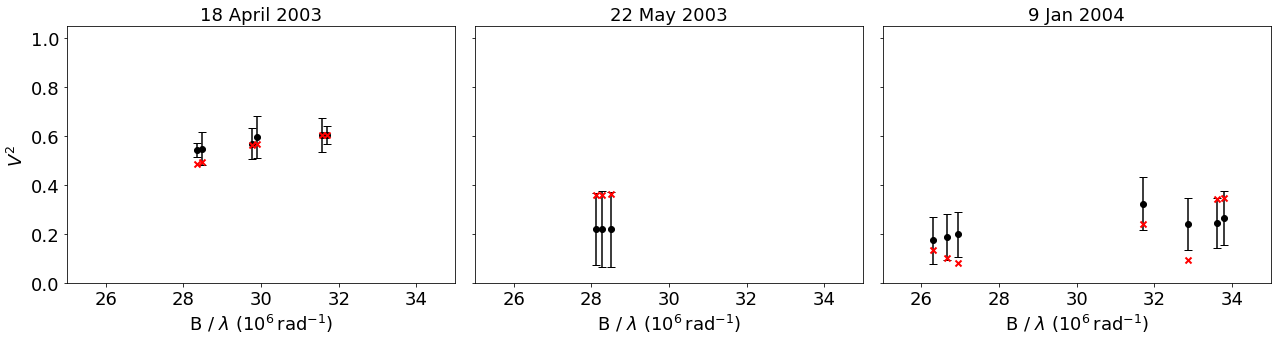

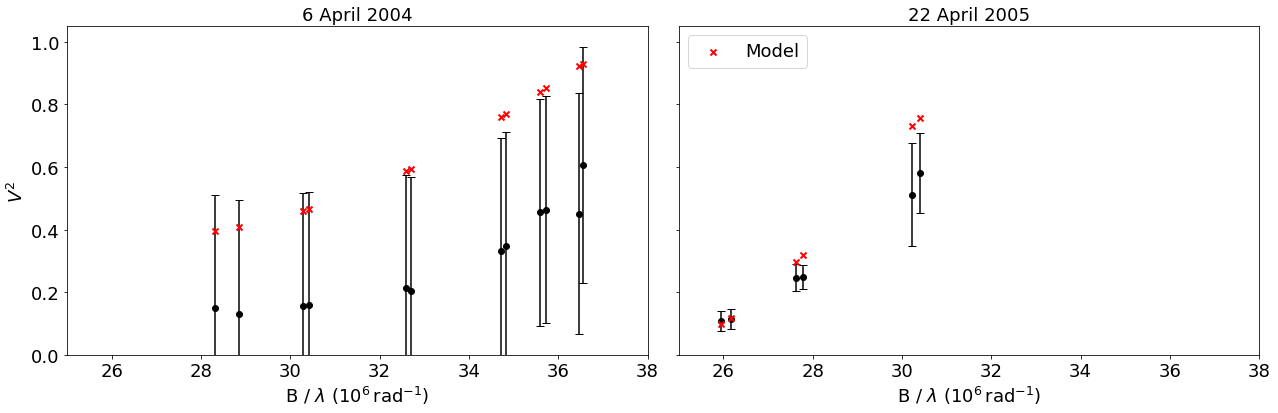

In [69]:
fig, ax = plt.subplots(1, 3, sharey=True)
fig.set_size_inches(18,5)

c =   1000 * np.pi/180/3600000.*1e6


x_v2model_a03 = np.median(trace['x_v2model_a03'])
y_v2model_a03 = np.median(trace['y_v2model_a03'])

x_v2model_a04 = np.median(trace['x_v2model_a04'])
y_v2model_a04 = np.median(trace['y_v2model_a04'])

x_v2model_a05 = np.median(trace['x_v2model_a05'])
y_v2model_a05 = np.median(trace['y_v2model_a05'])

x_v2model_j04 = np.median(trace['x_v2model_j04'])
y_v2model_j04 = np.median(trace['y_v2model_j04'])

x_v2model_m03 = np.median(trace['x_v2model_m03'])
y_v2model_m03 = np.median(trace['y_v2model_m03'])

B_a03 = np.sqrt(u_data_a03**2 + v_data_a03**2) / wavel_a03
B_a04 = np.sqrt(u_data_a04**2 + v_data_a04**2) / wavel_a04
B_a05 = np.sqrt(u_data_a05**2 + v_data_a05**2) / wavel_a05
B_m03 = np.sqrt(u_data_m03**2 + v_data_m03**2) / wavel_m03
B_j04 = np.sqrt(u_data_j04**2 + v_data_j04**2) / wavel_j04
        
model_v2_a03 = xy_to_V2(f,x_v2model_a03,y_v2model_a03, wavel_a03, u_data_a03, v_data_a03, 0)
model_v2_a04 = xy_to_V2(f,x_v2model_a04,y_v2model_a04, wavel_a04, u_data_a04, v_data_a04, 0)
model_v2_a05 = xy_to_V2(f,x_v2model_a05,y_v2model_a05, wavel_a05, u_data_a05, v_data_a05, 0)
model_v2_m03 = xy_to_V2(f,x_v2model_m03,y_v2model_m03, wavel_m03, u_data_m03, v_data_m03, 0)
model_v2_j04 = xy_to_V2(f,x_v2model_j04,y_v2model_j04, wavel_j04, u_data_j04, v_data_j04, 0)

# get the total errors
def get_err(rv_err, logjitter):
    return np.sqrt(rv_err**2 + np.exp(2*logjitter))        

ax[0].set_title('18 April 2003', fontsize=18)
ax[0].errorbar(B_a03, vis2_a03, yerr= get_err(vis_err_a03,  np.median(trace["logjitterV2_a03"])), fmt='ok', capsize=4)
ax[0].set_xlabel('B / $\lambda$ ($\mathrm{10^6\,rad^{-1}}$)', fontsize=18)
ax[0].set_ylabel('$V^{2}$', fontsize=18)
ax[0].scatter(B_a03,model_v2_a03, label='Model',marker='x', color='r', lw=2, zorder = 3)

ax[1].set_title('22 May 2003', fontsize=18)
ax[1].errorbar(B_m03, vis2_m03, yerr= get_err(vis_err_m03,  np.median(trace["logjitterV2_m03"])), fmt='ok', capsize=4)
ax[1].set_xlabel('B / $\lambda$ ($\mathrm{10^6\,rad^{-1}}$)', fontsize=18)
ax[1].scatter(B_m03,model_v2_m03, label='Model',marker='x', color='r', lw=2, zorder = 3)

ax[2].set_title('9 Jan 2004', fontsize=18)
ax[2].errorbar(B_j04, vis2_j04, yerr= get_err(vis_err_j04,  np.median(trace["logjitterV2_j04"])), fmt='ok', capsize=4)
ax[2].set_xlabel('B / $\lambda$ ($\mathrm{10^6\,rad^{-1}}$)', fontsize=18)
ax[2].scatter(B_j04,model_v2_j04, label='Model',marker='x', color='r', lw=2, zorder = 3)

plt.setp(ax,ylim=[0,1.05])
plt.setp(ax,xlim=[25,35])
#ax[2].legend(loc='upper left')

plt.tight_layout()
plt.savefig('Plots/V2_KI_A.pdf')

fig, axs = plt.subplots(1, 2, sharey=True)

axs[1].set_title('22 April 2005', fontsize=18)
axs[1].errorbar(B_a05, vis2_a05, yerr= get_err(vis_err_a05,  np.median(trace["logjitterV2_a05"])), fmt='ok', capsize=4)
axs[1].set_xlabel('B / $\lambda$ ($\mathrm{10^6\,rad^{-1}}$)', fontsize=18)
axs[1].scatter(B_a05,model_v2_a05, label='Model',marker='x', color='r', lw=2, zorder = 3)

axs[0].set_title('6 April 2004', fontsize=18)
axs[0].errorbar(B_a04, vis2_a04, yerr= get_err(vis_err_a04,  np.median(trace["logjitterV2_a04"])), fmt='ok', capsize=4, label = 'KI data')
axs[0].set_xlabel('B / $\lambda$ ($\mathrm{10^6\,rad^{-1}}$)', fontsize=18)
axs[0].set_ylabel('$V^{2}$', fontsize=18)
axs[0].scatter(B_a04,model_v2_a04, label='Model',marker='x', color='r', lw=2, zorder = 3)

plt.setp(axs,ylim=[0,1.05])
plt.setp(axs,xlim=[25,38])
axs[1].legend(loc='upper left', prop={'size': 18})
fig.set_size_inches(18,6)

plt.rcParams.update({'font.size': 15})

plt.tight_layout()
plt.savefig('Plots/V2_KI_B.pdf')
plt.show()

In [70]:
# Mutual inclination
n_sim=10000

deg2rad = np.pi/180
rad2deg = 180/np.pi 

# This work
i1 = np.random.normal(65.43,0.31,n_sim)
i2_a = np.random.normal(26,1,n_sim)
i2_b = np.random.normal(154,1,n_sim)
Omega1 = np.random.normal(344.02,0.32,n_sim)
Omega2 = np.random.normal(196,1,n_sim)

cos_angle_a = np.cos(i1*deg2rad)*np.cos(i2_a*deg2rad)+np.sin(i1*deg2rad)*np.sin(i2_a*deg2rad)*np.cos(Omega1*deg2rad-Omega2*deg2rad)
mutual_inc_new_a = np.arccos(cos_angle_a)*rad2deg

cos_angle_b = np.cos(i1*deg2rad)*np.cos(i2_b*deg2rad)+np.sin(i1*deg2rad)*np.sin(i2_b*deg2rad)*np.cos(Omega1*deg2rad-Omega2*deg2rad)
mutual_inc_new_b = np.arccos(cos_angle_b)*rad2deg


dist, dist_s = get_median_sigma(mutual_inc_new_a)

print("$\phi_{BaBb-Disk} (i=26)$: "+round(str(dist), uncertainty=str(dist_s), separation='$\pm$'))

dist, dist_s = get_median_sigma(mutual_inc_new_b)

print("$\phi_{BaBb-Disk} (i=154)$: "+round(str(dist), uncertainty=str(dist_s), separation='$\pm$'))

$\phi_{BaBb-Disk} (i=26)$: 87.9$\pm$0.9
$\phi_{BaBb-Disk} (i=154)$: 135.4$\pm$0.8


In [71]:

n_sim=10000

deg2rad = np.pi/180
rad2deg = 180/np.pi 

# This work
i1 = np.random.normal(135.59,0.12,n_sim)
i2_a = np.random.normal(65.43,0.31,n_sim)

Omega1 = np.random.normal(170.17,0.15,n_sim)
Omega2 = np.random.normal(342.02,0.32,n_sim)

cos_angle_a = np.cos(i1*deg2rad)*np.cos(i2_a*deg2rad)+np.sin(i1*deg2rad)*np.sin(i2_a*deg2rad)*np.cos(Omega1*deg2rad-Omega2*deg2rad)
mutual_inc_new_a = np.arccos(cos_angle_a)*rad2deg


dist, dist_s = get_median_sigma(mutual_inc_new_a)

print("$\phi_{AaAb-BaBb}$: "+round(str(dist), uncertainty=str(dist_s), separation='$\pm$'))



$\phi_{AaAb-BaBb}$: 158.0$\pm$0.3


In [72]:
# Mutual inclination
n_sim=10000

deg2rad = np.pi/180
rad2deg = 180/np.pi 

# This work
i1 = np.random.normal(135.59,0.12,n_sim)
i2_a = np.random.normal(26,1,n_sim)
i2_b = np.random.normal(154,1,n_sim)
Omega1 = np.random.normal(170.17,0.15,n_sim)
Omega2 = np.random.normal(196,1,n_sim)

cos_angle_a = np.cos(i1*deg2rad)*np.cos(i2_a*deg2rad)+np.sin(i1*deg2rad)*np.sin(i2_a*deg2rad)*np.cos(Omega1*deg2rad-Omega2*deg2rad)
mutual_inc_new_a = np.arccos(cos_angle_a)*rad2deg

cos_angle_b = np.cos(i1*deg2rad)*np.cos(i2_b*deg2rad)+np.sin(i1*deg2rad)*np.sin(i2_b*deg2rad)*np.cos(Omega1*deg2rad-Omega2*deg2rad)
mutual_inc_new_b = np.arccos(cos_angle_b)*rad2deg


dist, dist_s = get_median_sigma(mutual_inc_new_a)

print("$\phi_{AaAb-Disk} (i=26)$: "+round(str(dist), uncertainty=str(dist_s), separation='$\pm$'))

dist, dist_s = get_median_sigma(mutual_inc_new_b)

print("$\phi_{AaAb-Disk} (i=154)$: "+round(str(dist), uncertainty=str(dist_s), separation='$\pm$'))

$\phi_{AaAb-Disk} (i=26)$: 111$\pm$1
$\phi_{AaAb-Disk} (i=154)$: 23.4$\pm$0.7
